# Which contract should a household with no battery sign?

One question, asked three times, on the same Fluvius households the horizon study uses —
**`PER_GROUP` from each of the 8 groups** (plain, EV, HP, HP+EV, PV, PV+EV, PV+HP, PV+HP+EV),
full year, 15-minute intervals, **no battery anywhere in this notebook**. `PER_GROUP` is set in
section 0 and defaults to 5, i.e. 40 households; every table, chart and cache below follows it.

That last clause is what makes the question answerable at all. With no battery there is
**no dispatch decision**: the household imports exactly what it did not generate in the
interval it did not generate it, and exports the rest. There is nothing to optimize, no
MILP, no horizon — the annual bill is a pure function of the price list, and the answer
is simply the cheapest one. Which also makes it the reading to take *before* any battery
result, because it separates two very differently-priced problems:

> **"this household is on the wrong contract"** — fixed by a phone call, worth up to
> 20 % of the bill · **"this household needs a battery"** — worth ~30 kWh of hardware

### The three chapters

| | who | export credited at | asks |
|---|---|---|---|
| **1** | the 20 households with **no PV** | — nothing to export | which plain supply list, billed under `si_dobava` |
| **2** | the 20 households **with PV** | the list's own `tip_odkupa` | which *samooskrba* list, billed under `si_samooskrba` |
| **3** | the same 20 **with PV** | **zero** | the same lists for a household that may not sell |
| **4** | best 3 and worst 3 contracts, PV only | both | what the right to sell the surplus is actually worth |

Chapters 2 and 3 are the same computation with one term changed, which is the point: the
import side, the fixed charges and the excess-power charge are held identical, so
everything that moves between them is the buyback. Chapter 4 takes the **best 3 and the worst 3**
contracts and shows each of them under both regimes, so the value of the right to sell is read off
the same row rather than by flipping between two rankings.

### A contract is a price list *and* a meter

A Slovenian *tarifni* price list usually publishes **three** supplier rates: `VT` and `MT` for a
two-tariff meter, and a single `ET` rate for a one-tariff meter. They are alternative products on
the same cenik, and the household picks one when it picks its meter — so a comparison that
silently takes one of them is comparing suppliers on a choice the customer actually gets to make.

Every row in this notebook is therefore a **price option**: a list plus, where the supplier
publishes both, which variant is being billed.

| in the tables | what it means |
|---|---|
| `… [2T]` | two-tariff meter, billed `VT` in the high window and `MT` otherwise |
| `… [1T]` | single-tariff meter, billed the flat `ET` rate around the clock |
| no suffix | the list offers no such choice — a 4-block (*aktivni*) or spot-linked (*dinamični*) list, or a *tarifni* list that publishes only one of the two |

The `Structure` column spells out the actual rates behind each, so no table leaves it implicit.
Two asymmetries worth noticing before chapter 2: **`GEN-I Samo Redni` is 1T only** — GEN-I sells no
two-tariff *samooskrba* product at all — while **`Petrol Samooskrba` publishes both**, so it is the
one samooskrba list that appears twice. On the no-PV side of chapter 1 most lists appear twice,
which is why 15 price lists become 25 options.

### What "no PV" and "with PV" mean in this data

The Fluvius columns are **meter registers**, not gross load and gross production:
`Consumption_Volume_kWh` is grid offtake and `Feed_In_Volume_kWh` is grid injection, and
they are very nearly mutually exclusive — both non-zero in only 9.7 % of the 702 720
PV-household intervals (2.4 % to 14.2 % per household), which is the 15-minute aggregation
of a meter that netted at a finer resolution. So the roof's
**self-consumption has already been netted away before the data starts**, and no contract
term in this notebook can reach it. What every chapter prices is the *residual*: the
import that survived the roof, and the surplus it could not absorb. That is exactly what
a bill is measured on — but it means chapter 3 removes the value of the **surplus** only,
never the much larger saving the roof makes by displacing retail import in the first
place. A PV household here is not "a household that could go off-grid"; it is a
household whose meter shows 500–3 100 kWh/a going the other way.

### Runtime

Everything is cached to `Results/`, and every step is minutes rather than hours:

| chapter | cache | cost to recompute |
|---|---|---|
| 1 — no PV | `no_pv_tariff_comparison_pg{PER_GROUP}.csv` | ~50 s at `PER_GROUP = 5` |
| 2 — PV, credited | `pv_tariff_comparison_buyback_pg{PER_GROUP}.csv` | ~30 s |
| 3 — PV, no sale | `pv_tariff_comparison_nosale_pg{PER_GROUP}.csv` | ~15 s (the per-interval rates are already cached) |

There is no MILP in this notebook and no batch to wait on. Set the `RUN_*` flag above a
chapter to recompute it — and note that **each sample size gets its own cache**: the file name
carries `PER_GROUP` and every row records it, so changing the setting recomputes into a new file
rather than overwriting the old one or averaging one sample as if it were another. Switching back
to a size already run costs nothing.

In [59]:
### Imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, to_rgb
from matplotlib.patches import Patch

import importlib
import Horizon_Comparison as hc
hc = importlib.reload(hc)
from Pricing_Functions import PAKETI

RESULTS_DIR = hc.RESULTS_DIR.parent          # Results/, where the three caches live


def cache_path(name, per_group):
    """Cache file for one chapter at one sample size.

    The sample size is in the FILENAME, not just in a column: two settings then
    coexist instead of overwriting each other, so switching PER_GROUP back and
    forth costs nothing after the first run of each. The column is still checked
    on read -- the name says what a file should be, the column says what it is.
    """
    return RESULTS_DIR / f"{name}_pg{int(per_group)}.csv"
print(f"Horizon_Comparison loaded: {len(hc.consumer_price_lists())} plain supply lists, "
      f"{len(hc.prosumer_price_lists())} samooskrba lists.")

Horizon_Comparison loaded: 25 plain supply lists, 7 samooskrba lists.


## 0. What the bill is made of, and the one thing a contract cannot change

The study parameters live in `Horizon_Comparison.py`, the same module the horizon study
reads, so the two notebooks cannot drift apart on the household sample, the pricing
regime or the agreed billing power.

**`PER_GROUP` is the one knob here.** It sets how many households are drawn from each of the 8
Fluvius groups, and it is the same argument `hc.study_units` takes, so the sample stays a balanced
panel at any setting: raising it never changes the mix of household types, only how many of each.
The default 5 gives 40 households (20 no-PV, 20 with PV). Drop it to 1 or 2 for a fast pass while
editing, raise it toward `hc.HOUSEHOLDS_PER_GROUP` for the published run. Each comparison records
its own `Per_Group` on every row, so a cache written at one setting is recomputed rather than
misread at another.

The bill has three parts, and **only the first is competitive**:

| part | what it is | can a contract change it? |
|---|---|---|
| **energy** | supplier price + `omrežnina` energy rate per block + levies, ×1.22 VAT, **minus** the buyback credit on the surplus | yes — this is the whole spread between suppliers |
| **fixed** | `omrežnina` power rate × **agreed** power + OVE/SPTE + the supplier's monthly fee | only through the monthly fee and the agreed power, not the tariff structure |
| **excess power** | `omrežnina` power rate × (monthly peak − agreed power) × 1.05 | **no** — identical on every list, and identical in every chapter below |

The last two both move with the **agreed billing power** (*dogovorjena obračunska moč*),
which is modelled here as a household that manages the figure itself: every month it
agrees exactly the per-block peak the previous month realized, with no regulatory floor
and no connection-power ceiling, and only the Akt's monotonicity rule
(`P1 ≤ P2 ≤ P3 ≤ P4 ≤ P5`) applied. The leading month has no predecessor, so it is
bootstrapped from the last complete month of the same dataset
(`hc.AGREED_POWER_BOOTSTRAP = "cyclic"`). `MILP_horizon_comparison` section 1b has the
full argument for that rule and the alternatives; nothing about it differs here.

Two consequences worth holding on to before reading any table:

* **The excess-power charge is the same number on every list**, because it is a network
  charge, not a supply one. It is therefore *never* a reason to prefer one contract —
  it is the line a battery moves, which is why it belongs in this notebook only as a
  constant to be recognized and set aside.
* **Choosing your own agreed power is what makes that charge payable at all.** Since
  24. 4. 2025 a household up to 43 kW that leaves its assigned agreed power alone is
  permanently exempt. The household modelled here is not, and pays 1.05 × the block
  power rate on the exceedance in 2026.

In [60]:
PER_GROUP = 5        # households drawn from EACH Fluvius group; 1-2 for a fast pass

UNITS = hc.study_units(per_group=PER_GROUP)
NO_PV_UNITS = hc.study_units(hc.NO_PV_GROUPS, PER_GROUP)
PV_UNITS = hc.study_units(hc.PV_GROUPS, PER_GROUP)

print(f"households         : {PER_GROUP} per group = {len(UNITS)} units, no battery")
print(f"   no PV           : {len(NO_PV_UNITS)} units  "
      f"({', '.join(hc.NO_PV_GROUPS)})")
print(f"   with PV         : {len(PV_UNITS)} units  "
      f"({', '.join(hc.PV_GROUPS)})")
print(f"pricing regime     : {hc.PRICING_REFERENCE_YEAR}")
print(f"   no PV           : scheme {hc.CONSUMER_SCHEME} -- a plain supply contract")
print(f"   with PV         : scheme {hc.PROSUMER_SCHEME} -- netting INSIDE the 15-min "
      f"interval, then the surplus is credited")
print(f"agreed power       : {hc.AGREED_POWER_TAG}, leading month "
      f"{hc.AGREED_POWER_BOOTSTRAP!r}; identical in every chapter")
print(f"peak reset         : every {hc.PEAK_RESET_MONTHS} month(s), tag "
      f"{hc.PEAK_RESET_TAG!r} -- the excess-power charge is billed monthly")

# One row per price OPTION -- a list, plus which metering variant it is billed
# on where the supplier publishes both. `Structure` is the actual supplier rate,
# so which variant a row uses is never left to be inferred from the suffix.
consumer_options = hc.consumer_price_lists()
prosumer_options = hc.prosumer_price_lists()
n_consumer_lists = len({hc.option_base_id(o) for o in consumer_options})
n_prosumer_lists = len({hc.option_base_id(o) for o in prosumer_options})

print(f"\nplain supply options (chapter 1): {len(consumer_options)} "
      f"from {n_consumer_lists} price lists")
for o in consumer_options:
    p = PAKETI[hc.option_base_id(o)]
    print(f"   {hc.option_label(o):26s} {p.dobavitelj:18s} "
          f"{hc.tariff_structure_label(o):30s} fee {p.nadomestilo(True):.2f} EUR/mo")

print(f"\nsamooskrba options (chapters 2-4): {len(prosumer_options)} "
      f"from {n_prosumer_lists} price lists")
for o in prosumer_options:
    p = PAKETI[hc.option_base_id(o)]
    print(f"   {hc.option_label(o):26s} {p.dobavitelj:18s} "
          f"{hc.tariff_structure_label(o):30s} buyback: {hc.buyback_rate_label(o)}")

split = sorted({hc.option_base_id(o) for o in consumer_options + prosumer_options
                if hc.option_variant(o) != hc.VARIANT_NA})
print(f"\n{len(split)} lists publish BOTH a VT/MT and an ET rate and so appear twice: "
      f"{', '.join(split)}")
print("NET metering is left out on purpose: it is closed to new consents and settles "
      "once a year,\nso it is neither a list a household can choose into nor a bill a "
      "per-interval evaluator can write.")

households         : 5 per group = 40 units, no battery
   no PV           : 20 units  (Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV)
   with PV         : 20 units  (Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV)
pricing regime     : 2026
   no PV           : scheme si_dobava -- a plain supply contract
   with PV         : scheme si_samooskrba -- netting INSIDE the 15-min interval, then the surplus is credited
agreed power       : prev1m_cyclic_unbounded, leading month 'cyclic'; identical in every chapter
peak reset         : every 1 month(s), tag '1m' -- the excess-power charge is billed monthly

plain supply options (chapter 1): 25 from 15 price lists
   BISOL_DINAMICNI            BISOL Energija     dynamic: SIPX + 0.01300        fee 1.63 EUR/mo
   BISOL_DINAMICNI_PLUS       BISOL Energija     dynamic: SIPX + 0.01300        fee 3.26 EUR/mo
   BISOL_FIKSNI [2T]          BISOL Energija     2T: VT 0.12700 / MT 0.10700    fee 1.63 EUR/mo
   BISOL_FIKSNI [1T]          BISOL

In [61]:
### Shared chart styling
# ---------------------------------------------------------------------------
# What the colour channel means in THIS notebook, and it means only this:
#
#   hue      ONE categorical question per chapter, and only ever one of these
#            two, because no chart in the notebook asks both at once:
#
#              chapters 2-4  the export regime -- exports credited (blue) vs
#                            no sale (orange). Validated all-pairs against the
#                            #fcfcfb surface: normal-vision OKLab dE 33.6
#                            (floor 15), protan 24.7 / deutan 31.7 (target 8),
#                            contrast 4.30 and 3.12 (min 3.0).
#              chapter 5     the catalogue -- plain supply (purple) vs
#                            samooskrba (green), on charts where every row is
#                            already under the same zeroed export regime and the
#                            regime channel is therefore free. Same checks:
#                            normal dE 34.6, protan 27.5 / deutan 18.5,
#                            contrast 5.51 and 3.36. (The green is checked
#                            against the regime pair too and clears blue at
#                            25.6/25.5, but sits at protan 6.1 against the
#                            orange -- which is why the two pairs are never
#                            drawn in the same axes.)
#
#   ramp     magnitude -- ONE hue, light -> dark. A ranked list of price lists
#            is a magnitude chart whose identity comes off the labelled axis,
#            so it never gets six competing hues. Where the rows of a magnitude
#            panel come from both catalogues the ramp is NEUTRAL, so the
#            magnitude cannot be misread as a category.
#   shade    household type, a neutral ramp light -> dark by annual demand.
#
# Nothing here is ever the *rank* of a bar: a filter that drops a list must
# not repaint the survivors.
REGIME_COLOR = {"credited": "#2a78d6", "nosale": "#eb6834"}
REGIME_LABEL = {"credited": "presežke odkupi dobavitelj",
                "nosale":   "presežkov ni mogoče prodati"}
CATALOGUE_ORDER = ("dobava", "samooskrba")
CATALOGUE_COLOR = {"dobava": "#a03fa0", "samooskrba": "#2f9e44"}
CATALOGUE_SHORT = {"dobava": "dobava", "samooskrba": "samooskrba"}
CATALOGUE_LABEL = {
    "dobava": "cenik za dobavo brez samooskrbe (odjemalec s PV ga ne sme podpisati)",
    "samooskrba": "samooskrbni cenik, presežki ovrednoteni z 0 EUR",
}
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})


def _mix(hex_color, other, t):
    """Blend two hex colours, t = share of `other`."""
    a = np.array(to_rgb(hex_color))
    b = np.array(to_rgb(other))
    return tuple((1.0 - t) * a + t * b)


def ramp(hex_color, name="ramp"):
    """Sequential ramp built from one hue: light -> dark, for magnitude panels."""
    return LinearSegmentedColormap.from_list(
        name, [SURFACE, _mix(hex_color, "#ffffff", 0.55), hex_color,
               _mix(hex_color, "#0b0b0b", 0.42)])


def group_label(dataset):
    """Household type as a chart label: the dataset prefix carries no meaning."""
    return "osnovni" if dataset == "Fluvius" else str(dataset).replace("Fluvius_", "")


def group_shades(groups, base=INK_2):
    """One neutral shade per household type, light -> dark by position.

    Household type is ORDERED (plain -> EV -> HP -> HP+EV, by annual demand), so
    it gets a single hue ramped rather than a categorical palette -- the
    categorical channel stays reserved for the export regime.
    """
    return [_mix(base, "#ffffff", t) for t in np.linspace(0.72, 0.05, len(groups))]


def short_list_name(option_id, variant=True):
    """Chart-axis label for one price OPTION.

    The metering variant is part of the identity, not a footnote: two rows that
    read "GEN-I Redni" and differ by 8 EUR/a would be unreadable, so a list that
    publishes both a VT/MT and an ET rate always carries its [2T]/[1T] tag.
    """
    base = hc.option_base_id(option_id)
    name = (base.replace("GENI_SAMO_", "GEN-I Samo ").replace("GENI_", "GEN-I ")
            .replace("BISOL_SAMO_", "BISOL Samo ").replace("BISOL_", "BISOL ")
            .replace("PETROL_", "Petrol ").replace("ELEN_", "El. energija ")
            .replace("_", " ").title()
            .replace("Gen-I", "GEN-I").replace("Bisol", "BISOL"))
    tag = hc.option_variant(option_id)
    return f"{name} [{tag}]" if variant and tag != hc.VARIANT_NA else name


def below_legend(ax, handles=None, labels=None, ncol=4, y=-0.155, **kw):
    """Legend under the x-axis label rather than inside the plot area.

    A horizontal bar chart with a full-width bar in every row has no free
    corner, so an inside legend lands on top of data. This is the only
    placement that cannot collide, and it keeps the reading order
    title -> bars -> axis -> key.
    """
    args = ([] if handles is None else [handles, labels])
    return ax.legend(*args, loc="upper center", bbox_to_anchor=(0.5, y),
                     ncol=ncol, fontsize=8, **kw)


def bar_labels(ax, ypos, values, fmt="{:.0f}", pad=None, color=INK_2, fontsize=8):
    """Direct value labels at the end of horizontal bars.

    Every panel below is directly labelled rather than read off the grid: the
    numbers are euros a household would pay, and a 4 EUR/a difference between
    two lists is invisible at bar length but decisive at the till.
    """
    span = float(np.max(values)) if len(values) else 1.0
    pad = span * 0.012 if pad is None else pad
    for y, v in zip(ypos, values):
        ax.text(v + pad, y, fmt.format(v), va="center", ha="left",
                fontsize=fontsize, color=color)


def ranked_bill_panel(ax, summary, hue, title, xlabel, best_marker=True):
    """One ranked horizontal bar chart of the mean annual bill per price list.

    Identity is on the y axis, magnitude in the bar, so this is a single-hue
    ramp: darkest for the cheapest list. The cheapest row is called out in
    words as well as in shade, so the ranking never rests on colour alone.
    """
    n = len(summary)
    shades = [_mix(hue, "#ffffff", t) for t in np.linspace(0.0, 0.62, n)]
    ypos = np.arange(n)[::-1]
    ax.barh(ypos, summary["Cost_EUR"], height=0.68, color=shades)
    ax.set_yticks(ypos, [short_list_name(p) for p in summary.index], fontsize=8.5)
    bar_labels(ax, ypos, summary["Cost_EUR"].to_numpy())
    if best_marker:
        ax.text(summary["Cost_EUR"].iloc[0] * 0.5, ypos[0], "najcenejši",
                va="center", ha="center", fontsize=8, color="#ffffff",
                fontweight="semibold")
    ax.set_xlim(0, summary["Cost_EUR"].max() * 1.14)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left")
    ax.grid(axis="x")
    ax.spines["left"].set_visible(False)
    return ypos


def overpay_heatmap(ax, table, hue, title, cbar_label="% nad najboljšim", fig=None,
                    cell_fontsize=7.5, label_fontsize=8, fmt="{:.1f}"):
    """Per-household-type overpayment against that group's own cheapest list.

    A magnitude with a meaningful floor at 0 %, so: one hue, light -> dark, and
    every cell carries its number because a heatmap alone is not readable to a
    colour-blind reader. The two font sizes are arguments because the same panel
    is drawn at 6 rows and at 32: the defaults are the 6-row setting.
    """
    values = table.to_numpy()
    im = ax.imshow(values, cmap=ramp(hue, "overpay"), aspect="auto",
                   vmin=0, vmax=float(np.nanmax(values)))
    ax.set_xticks(range(table.shape[1]),
                  [group_label(c) for c in table.columns],
                  rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(table.shape[0]),
                  [short_list_name(p) for p in table.index], fontsize=label_fontsize)
    ax.grid(False)
    cut = float(np.nanmax(values)) * 0.62
    for r in range(values.shape[0]):
        for c in range(values.shape[1]):
            ax.text(c, r, fmt.format(values[r, c]), ha="center", va="center",
                    fontsize=cell_fontsize,
                    color="#ffffff" if values[r, c] > cut else INK)
    ax.set_title(title, loc="left")
    if fig is not None:
        fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, label=cbar_label)
    return im


print("Style ready: hue = one categorical question per chapter (export regime in 2-4, "
      "catalogue in 5),\nboth pairs validated all-pairs; ramps = magnitude, "
      "shades = household type.")

Style ready: hue = one categorical question per chapter (export regime in 2-4, catalogue in 5),
both pairs validated all-pairs; ramps = magnitude, shades = household type.


## 1. Which price list should a household with **no PV** sign?

The chapter the horizon study could not answer with its own four price lists.
The four lists the horizon study runs are all *samooskrba* lists except `Redni 2T`, and three of them carry
`zahteva_pv=True` in the catalogue — they are only sold together with a self-consumption
device. A household with no PV chooses from the plain supply lists instead, billed under
`si_dobava`.

With **no PV and no battery there is no dispatch decision at all**: the household imports
exactly what it consumes, in the interval it consumes it. So this is a pure price-list
question and the answer is simply the cheapest annual bill. That is also what makes it the
right baseline to read before any battery result — it separates "this household is on the
wrong contract" from "this household needs a battery", and the two are worth very different
amounts.

The bill is built from three parts, and only the first differs between suppliers:

| part | what it is | can a contract change it? |
|---|---|---|
| **energy** | supplier price + `omrežnina` energy rate per block + levies, ×1.22 VAT | yes — this is the whole competitive spread |
| **fixed** | `omrežnina` power rate × **agreed** power + OVE/SPTE + supplier monthly fee | only via the agreed power, not the list |
| **excess power** | `omrežnina` power rate × (monthly peak − agreed power) × 1.05 | no — identical on every list |

The last two both move with the agreed billing power, which section 0 re-sets every month from the previous month's peak; the 1.05 weighting on the exceedance is the 2026 value (0.9 through 2025, 1.20 from 2028).

`Delta` is measured against the cheapest list **for that same household**, then averaged, so
a list is not flattered by a household mix that happens to suit it. `Cheapest for` counts the
households it actually wins.

In [62]:
### Every no-PV household on every list it could actually sign, zero battery
# ~30 s: the per-interval unit rate depends only on the calendar and the market
# price, never on the household, so one pass per list prices all 20 households.
NO_PV_CACHE = cache_path("no_pv_tariff_comparison", PER_GROUP)
RUN_NO_PV = True        # True -> recompute instead of reading the cache

# The cache is keyed on the agreed-power rule as well: these bills are mostly
# network charges, and a cache written against a different dogovorjena moc is a
# different bill, not an older one.
cached = pd.read_csv(NO_PV_CACHE) if NO_PV_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
# A frame built on a different PER_GROUP is a different sample, not an older
# one -- reading it back would silently change every mean in the tables below.
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_NO_PV or cached is None:
    df_no_pv = hc.no_pv_tariff_comparison(per_group=PER_GROUP, verbose=True)
    df_no_pv.to_csv(NO_PV_CACHE, index=False)
else:
    df_no_pv = cached

no_pv_summary = hc.summarize_no_pv_tariffs(df_no_pv)
best_list = no_pv_summary.index[0]

print(f"{df_no_pv['Household'].nunique() * df_no_pv['Dataset'].nunique()} households "
      f"({', '.join(hc.NO_PV_GROUPS)}), {len(no_pv_summary)} price options from "
      f"{df_no_pv['Paket_ID'].nunique()} lists, no battery, full year under si_dobava\n")
print(f"cheapest on average : {best_list}  "
      f"({no_pv_summary.loc[best_list, 'Cost_EUR']:.0f} EUR/a, "
      f"cheapest for {no_pv_summary.loc[best_list, 'Cheapest_For']} of "
      f"{int(no_pv_summary.loc[best_list, 'Households'])} households)")
print(f"most expensive      : {no_pv_summary.index[-1]}  "
      f"({no_pv_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{no_pv_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{no_pv_summary['Cost_EUR'].iloc[-1] - no_pv_summary['Cost_EUR'].iloc[0]:.0f} EUR/a")

no_pv_summary.rename(columns={
    "Households": "Households",
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

  Fluvius 1: 2255 kWh
  Fluvius 2: 2513 kWh
  Fluvius 3: 2864 kWh
  Fluvius 4: 2765 kWh
  Fluvius 5: 734 kWh
  Fluvius_EV 1: 3194 kWh
  Fluvius_EV 2: 10023 kWh
  Fluvius_EV 3: 3824 kWh
  Fluvius_EV 4: 6395 kWh
  Fluvius_EV 5: 3923 kWh
  Fluvius_HP 1: 10335 kWh
  Fluvius_HP 2: 9230 kWh
  Fluvius_HP 3: 6827 kWh
  Fluvius_HP 4: 9198 kWh
  Fluvius_HP 5: 9969 kWh
  Fluvius_HP_EV 1: 10145 kWh
  Fluvius_HP_EV 2: 16413 kWh
  Fluvius_HP_EV 3: 9537 kWh
  Fluvius_HP_EV 4: 5761 kWh
  Fluvius_HP_EV 5: 4606 kWh
20 households (Fluvius, Fluvius_EV, Fluvius_HP, Fluvius_HP_EV), 25 price options from 15 lists, no battery, full year under si_dobava

cheapest on average : BISOL_FIKSNI99@1T  (1240 EUR/a, cheapest for 13 of 20 households)
most expensive      : PETROL_REDNI@1T  (1396 EUR/a, 13.1 % above the best available)
spread, best to worst: 156 EUR/a


,Supplier,Structure,Variant,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy [EUR/a],fixed [EUR/a],excess power [EUR/a],cheapest for
Option,,,,,,,,,,,,
BISOL_FIKSNI99@1T,BISOL Energija,1T: ET 0.09900,1T,20,1239.88,7.36,0.64,4.84,955.93,273.68,10.27,13
BISOL_FIKSNI99@2T,BISOL Energija,2T: VT 0.10900 / MT 0.09400,2T,20,1250.56,18.03,1.62,3.80,966.60,273.68,10.27,0
GENI_DINAMICNI,GEN-I,dynamic: SIPX + 0.01199,-,20,1272.54,40.02,3.72,8.44,983.61,278.66,10.27,5
ELEN_DINAMICNA,Elektro energija,dynamic: SIPX + 0.01199,-,20,1275.32,42.80,4.06,9.06,983.61,281.44,10.27,0
BISOL_FIKSNI_VEZAVA@2T,BISOL Energija,2T: VT 0.11600 / MT 0.09600,2T,20,1283.30,50.78,4.24,6.36,999.35,273.68,10.27,0
BISOL_FIKSNI_VEZAVA@1T,BISOL Energija,1T: ET 0.10500,1T,20,1287.65,55.12,4.37,9.30,1003.70,273.68,10.27,0
GENI_REDNI@2T,GEN-I,2T: VT 0.11990 / MT 0.09790,2T,20,1295.79,63.26,4.83,6.54,1021.21,264.31,10.27,1
BISOL_DINAMICNI,BISOL Energija,dynamic: SIPX + 0.01300,-,20,1296.96,64.44,5.50,10.98,1013.01,273.68,10.27,0
GENI_REDNI@1T,GEN-I,1T: ET 0.10890,1T,20,1309.33,76.80,5.66,11.36,1034.75,264.31,10.27,0


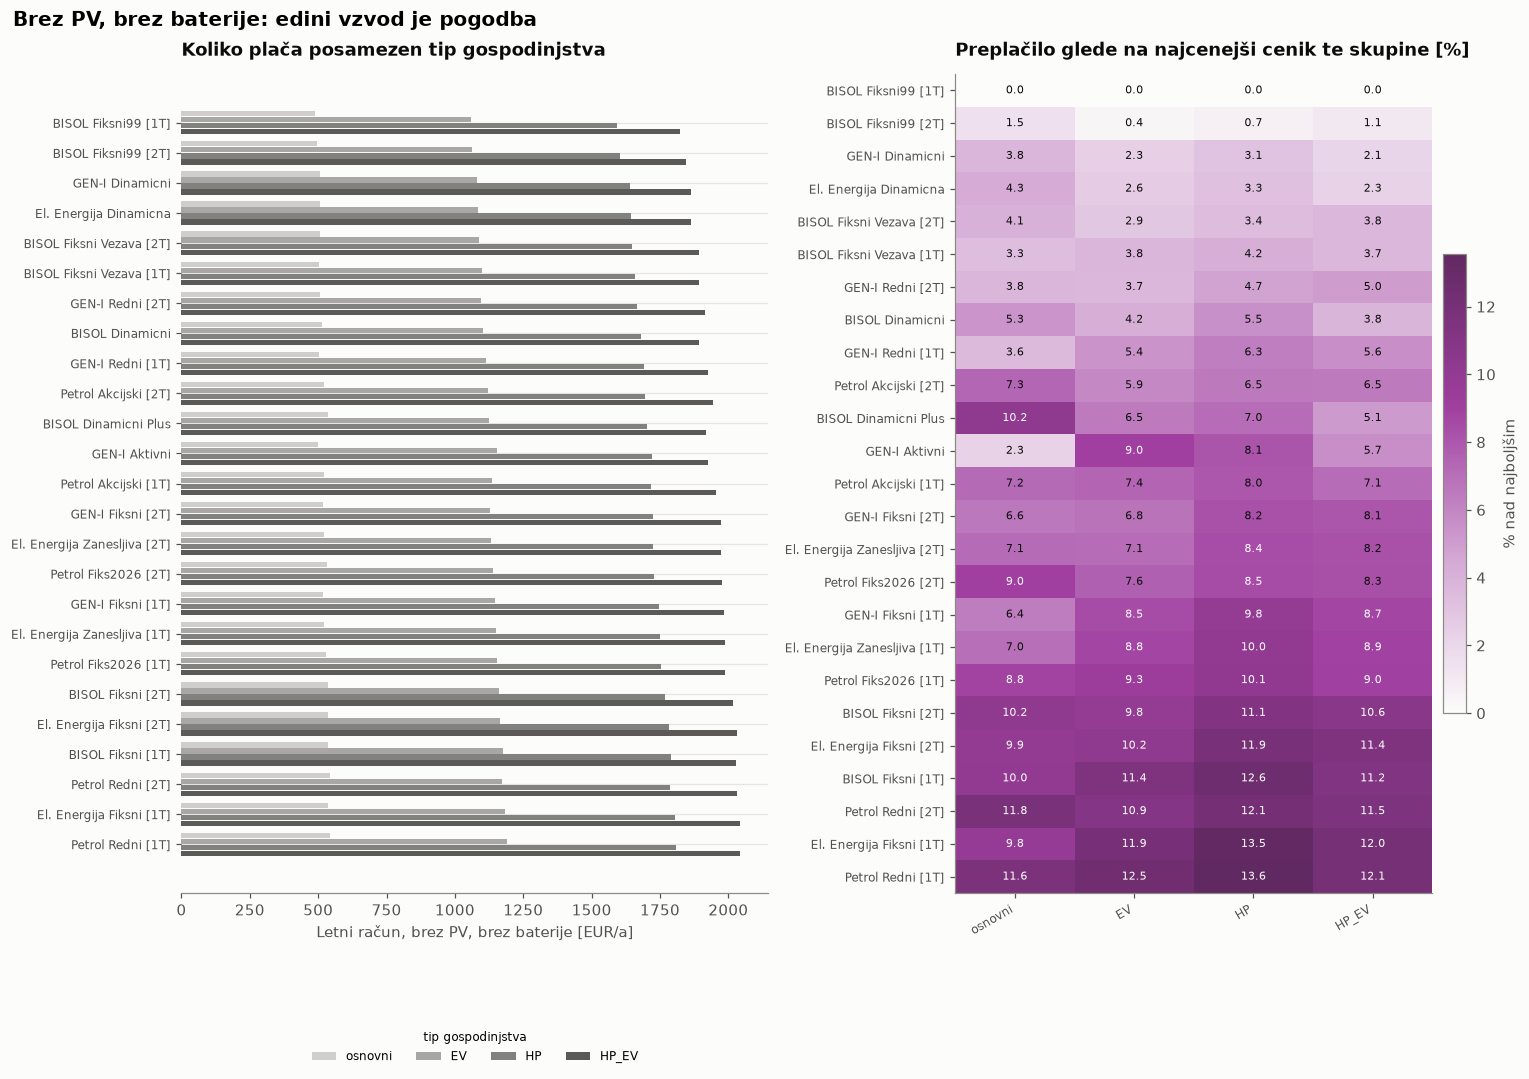

Dataset,Fluvius,Fluvius_EV,Fluvius_HP,Fluvius_HP_EV
Option,,,,
BISOL_FIKSNI99@1T,0.00,0.00,0.00,0.00
BISOL_FIKSNI99@2T,1.52,0.42,0.67,1.11
GENI_DINAMICNI,3.77,2.33,3.10,2.10
ELEN_DINAMICNA,4.34,2.59,3.28,2.25
BISOL_FIKSNI_VEZAVA@2T,4.07,2.88,3.45,3.76
BISOL_FIKSNI_VEZAVA@1T,3.35,3.79,4.19,3.73
GENI_REDNI@2T,3.78,3.67,4.74,4.99
BISOL_DINAMICNI,5.31,4.22,5.55,3.81
GENI_REDNI@1T,3.60,5.36,6.32,5.64


In [63]:
### The same ranking per household type, absolute and relative to that group's best
by_group_cost = df_no_pv.pivot_table(index="Option", columns="Dataset",
                                     values="Cost_EUR").reindex(no_pv_summary.index)
by_group_rel = 100.0 * (by_group_cost / by_group_cost.min() - 1.0)

groups = list(by_group_cost.columns)
GROUP_SHADE = group_shades(groups)

fig, axes = plt.subplots(1, 2, figsize=(14.0, max(6.4, 0.40 * len(by_group_cost))),
                         gridspec_kw={"width_ratios": [1.15, 1]})

ypos = np.arange(len(by_group_cost))[::-1]
bar_h = 0.80 / len(groups)
for i, g in enumerate(groups):
    axes[0].barh(ypos + 0.40 - bar_h * (i + 0.5), by_group_cost[g],
                 height=bar_h * 0.86, color=GROUP_SHADE[i], label=group_label(g))
axes[0].set_yticks(ypos, [short_list_name(p) for p in by_group_cost.index],
                   fontsize=8)
axes[0].set_xlabel("Letni račun, brez PV, brez baterije [EUR/a]")
axes[0].set_title("Koliko plača posamezen tip gospodinjstva", loc="left")
below_legend(axes[0], ncol=4, title="tip gospodinjstva", title_fontsize=8)
axes[0].grid(axis="x")
axes[0].spines["left"].set_visible(False)

# Relative penalty against the cheapest list for that same household type: a
# magnitude with a meaningful floor at 0 %, so one hue ramped light -> dark.
# No PV means no export, so this chapter is priced under neither regime -- it
# takes the neutral third slot rather than borrowing either regime's hue.
overpay_heatmap(axes[1], by_group_rel, "#a03fa0",
                "Preplačilo glede na najcenejši cenik te skupine [%]", fig=fig)

fig.suptitle("Brez PV, brez baterije: edini vzvod je pogodba",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

by_group_rel.round(2)

In [64]:
### Read-out: what the contract is worth next to what a battery is worth
lines = [f"{'list':24s}{'bill [EUR/a]':>14s}{'vs best [EUR/a]':>17s}{'vs best [%]':>13s}"]
for pid, row in no_pv_summary.iterrows():
    mark = "  <- cheapest" if pid == best_list else ""
    lines.append(f"{short_list_name(pid):24s}{row['Cost_EUR']:>14.2f}"
                 f"{row['Delta_EUR']:>17.2f}{row['Delta_pct']:>12.2f}%{mark}")

worst = no_pv_summary.index[-1]
switch_gain = no_pv_summary.loc[worst, "Cost_EUR"] - no_pv_summary.loc[best_list, "Cost_EUR"]
lines += [
    "",
    f"Switching from the worst option ({short_list_name(worst)}) to the best "
    f"({short_list_name(best_list)}) is worth "
    f"{switch_gain:.0f} EUR/a on average,",
    f"or {100 * switch_gain / no_pv_summary.loc[worst, 'Cost_EUR']:.1f} % of the bill -- "
    f"with no hardware, no dispatch and no battery.",
    "",
    "The three components, averaged over the households:",
    f"   energy (competitive)      {no_pv_summary['Energy_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {no_pv_summary['Energy_EUR'].max() - no_pv_summary['Energy_EUR'].min():.2f}",
    f"   fixed (agreed power etc.) {no_pv_summary['Fixed_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {no_pv_summary['Fixed_EUR'].max() - no_pv_summary['Fixed_EUR'].min():.2f}",
    f"   excess power (network)    {no_pv_summary['Excess_Power_EUR'].mean():8.2f} EUR/a  "
    f"identical on every list by construction",
    "",
    "The excess-power line is the only network item a battery can move, and it is the "
    "same number on every",
    "contract -- which is why the price list, not the network tariff, decides this "
    "question for a household with no PV.",
]

# --- 1T vs 2T, on the lists that publish both --------------------------------
pairs = sorted({hc.option_base_id(o) for o in no_pv_summary.index
                if hc.option_variant(o) != hc.VARIANT_NA})
if pairs:
    lines += ["", f"The METER, on the {len(pairs)} lists that publish both a VT/MT and an "
                  f"ET rate (2T minus 1T, so negative means 2T is cheaper):",
              f"   {'list':22s}" + "".join(f"{group_label(g):>10s}"
                                           for g in hc.NO_PV_GROUPS) + f"{'overall':>10s}"]
    by_variant = df_no_pv.pivot_table(index="Option", columns="Dataset", values="Cost_EUR")
    flips = 0
    for base in pairs:
        two, one = f"{base}@{hc.VARIANT_2T}", f"{base}@{hc.VARIANT_1T}"
        diff = by_variant.loc[two] - by_variant.loc[one]
        overall = no_pv_summary.loc[two, "Cost_EUR"] - no_pv_summary.loc[one, "Cost_EUR"]
        flips += int(diff.min() < 0 < diff.max())
        lines.append(f"   {short_list_name(base, variant=False):22s}"
                     + "".join(f"{diff[g]:>10.2f}" for g in hc.NO_PV_GROUPS)
                     + f"{overall:>10.2f}")
    lines += [
        "",
        f"The sign flips with the household type on {flips} of the {len(pairs)} lists: a "
        f"two-tariff meter only pays off for a",
        "household that moves enough demand into the MT window, and an EV or a heat pump is "
        "exactly what does that.",
        "So the meter is not a supplier-level decision -- it is a household-level one, taken "
        "on the same cenik,",
        "which is why every row above is tagged [2T] or [1T] rather than averaged into one "
        "line per list.",
        "",
        "Several lists show the SAME figure because the difference depends only on the "
        "VT-MT and VT-ET spreads,",
        "not on the price level, and most suppliers publish the same spreads "
        "(VT-MT 0.022, VT-ET 0.011). It is the",
        "level that separates those lists in the ranking above; the meter decision inside "
        "each of them is the same one.",
    ]
print("\n".join(lines))

list                      bill [EUR/a]  vs best [EUR/a]  vs best [%]
BISOL Fiksni99 [1T]            1239.88             7.36        0.64%  <- cheapest
BISOL Fiksni99 [2T]            1250.56            18.03        1.62%
GEN-I Dinamicni                1272.54            40.02        3.72%
El. Energija Dinamicna         1275.32            42.80        4.06%
BISOL Fiksni Vezava [2T]       1283.30            50.78        4.24%
BISOL Fiksni Vezava [1T]       1287.65            55.12        4.37%
GEN-I Redni [2T]               1295.79            63.26        4.83%
BISOL Dinamicni                1296.96            64.44        5.50%
GEN-I Redni [1T]               1309.33            76.80        5.66%
Petrol Akcijski [2T]           1319.87            87.35        7.32%
BISOL Dinamicni Plus           1320.82            88.30        8.40%
GEN-I Aktivni                  1324.69            92.16        6.90%
Petrol Akcijski [1T]           1332.18            99.66        8.08%
GEN-I Fiksni [2T]    

## 2. Which *samooskrba* list should a household **with PV** sign?

The same question, now for a roof. It is a different question rather than the same one
with more rows, because a PV household is choosing from a different catalogue and being
billed under a different scheme.

**Different catalogue.** All six lists here carry `zahteva_pv=True`: they are sold only
with a self-consumption device, and a household with no roof cannot sign any of them —
which is the mirror image of chapter 1, where a roof could not sign anything on offer.
The one legacy product, NET metering, is left out: it settles once a year rather than per
interval, and it is closed to new consents.

**Different scheme.** `si_samooskrba` nets **inside the 15-minute interval** and then
prices the residual. So the list decides two numbers, not one:

| | | who wins on it |
|---|---|---|
| the **import** price of the kWh the roof did not cover | as in chapter 1 | the flat and dynamic lists |
| the **buyback** credit on the surplus it could not absorb | `tip_odkupa`, and it is **not** the import price in reverse | see below |

That second line is worth being precise about, because it is where the intuition
"exporting is just importing backwards" fails. An exported kWh carries **no network
charge, no levy and no VAT** — it is a credit against the bill, not a delivered good.
On `GEN-I Samo Redni` the household imports at 0.10290 EUR/kWh of supplier price but
0.15056 delivered, and exports at 0.05390 flat. On the dynamic lists the credit is
`SIPX − pribitek` and can go **negative** when SIPX does, at exactly the hours a
south-facing roof is producing hardest.

`Delta` is measured against the cheapest list **for that same household**, then averaged,
so a list is never flattered by a household mix that suits it. `Cheapest for` counts the
households it actually wins.

In [65]:
### Every PV household on every samooskrba list it could sign, zero battery
# ~30 s: the per-interval import rate and export credit depend only on the
# calendar and the market price, never on the household, so one pass per list
# prices all 20.
PV_CACHE = cache_path("pv_tariff_comparison_buyback", PER_GROUP)
RUN_PV = False        # True -> recompute instead of reading the cache

# Keyed on the agreed-power rule as well: these bills are mostly network
# charges, and a cache written against a different dogovorjena moc is a
# different bill, not an older one.
cached = pd.read_csv(PV_CACHE) if PV_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_PV or cached is None:
    df_pv = hc.pv_tariff_comparison(per_group=PER_GROUP, buyback=True, verbose=True)
    df_pv.to_csv(PV_CACHE, index=False)
else:
    df_pv = cached

pv_summary = hc.summarize_pv_tariffs(df_pv)
pv_best = pv_summary.index[0]
pv_units = df_pv.groupby(["Dataset", "Household"]).ngroups

print(f"{pv_units} households ({', '.join(hc.PV_GROUPS)}), {len(pv_summary)} samooskrba "
      f"options from {df_pv['Paket_ID'].nunique()} lists, no battery, full year under "
      f"{hc.PROSUMER_SCHEME}")
print(f"meter registers      : {df_pv['Import_kWh'].mean():.0f} kWh/a offtake, "
      f"{df_pv['Export_kWh'].mean():.0f} kWh/a injection on average "
      f"(export/import ratio {df_pv['Export_kWh'].mean() / df_pv['Import_kWh'].mean():.2f})\n")
print(f"cheapest on average  : {pv_best}  "
      f"({pv_summary.loc[pv_best, 'Cost_EUR']:.0f} EUR/a, cheapest for "
      f"{pv_summary.loc[pv_best, 'Cheapest_For']} of {pv_units} households)")
print(f"most expensive       : {pv_summary.index[-1]}  "
      f"({pv_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{pv_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{pv_summary['Cost_EUR'].iloc[-1] - pv_summary['Cost_EUR'].iloc[0]:.0f} EUR/a")
print(f"buyback credit       : {pv_summary['Export_Credit_EUR'].min():.0f} to "
      f"{pv_summary['Export_Credit_EUR'].max():.0f} EUR/a depending on the list, "
      f"on identical exported energy")

pv_summary.rename(columns={
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy net [EUR/a]",
    "Import_EUR": "import [EUR/a]",
    "Export_Credit_EUR": "buyback credit [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Export_kWh": "exported [kWh/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

KeyError: 'PETROL_SAMO_MESECNI'

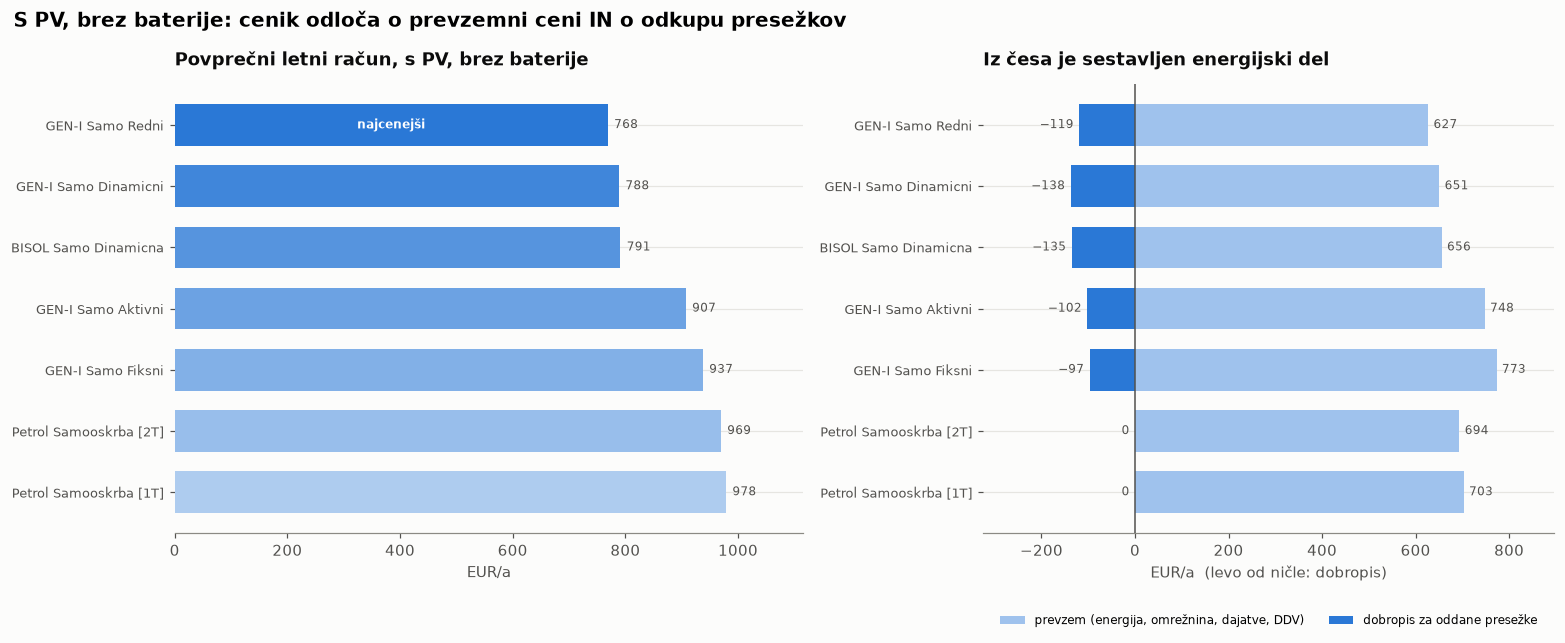

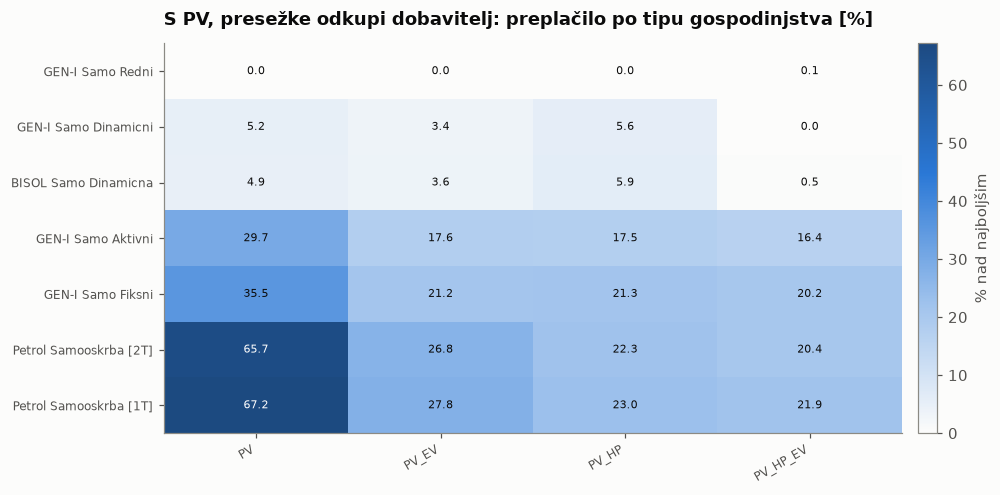

Dataset,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,
GENI_SAMO_REDNI,0.00,0.00,0.00,0.15
GENI_SAMO_DINAMICNI,5.15,3.37,5.62,0.00
BISOL_SAMO_DINAMICNA,4.91,3.61,5.86,0.49
GENI_SAMO_AKTIVNI,29.72,17.62,17.54,16.39
GENI_SAMO_FIKSNI,35.53,21.25,21.29,20.24
PETROL_SAMOOSKRBA@2T,65.72,26.82,22.29,20.37
PETROL_SAMOOSKRBA@1T,67.18,27.78,23.02,21.92


In [ ]:
### The ranking, and where each list's bill comes from
by_group_pv = df_pv.pivot_table(index="Option", columns="Dataset",
                                values="Cost_EUR").reindex(pv_summary.index)
by_group_pv_rel = 100.0 * (by_group_pv / by_group_pv.min() - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.0),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ranked_bill_panel(axes[0], pv_summary, REGIME_COLOR["credited"],
                  "Povprečni letni račun, s PV, brez baterije",
                  "EUR/a")

# The composition, on the same row order: what the household pays for import,
# and how much of it the buyback gives back. Two stacked parts of ONE bar with
# a 2 px surface gap between them -- not a second axis, and not a second chart,
# because the credit is only meaningful next to the import it offsets.
ypos = np.arange(len(pv_summary))[::-1]
imp = pv_summary["Import_EUR"].to_numpy()
cred = pv_summary["Export_Credit_EUR"].to_numpy()
axes[1].barh(ypos, imp, height=0.68, color=_mix(REGIME_COLOR["credited"], "#ffffff", 0.55),
             label="prevzem (energija, omrežnina, dajatve, DDV)")
axes[1].barh(ypos, -cred, height=0.68, color=REGIME_COLOR["credited"],
             label="dobropis za oddane presežke")
axes[1].axvline(0, color=INK_2, lw=1.0, zorder=4)
axes[1].set_yticks(ypos, [short_list_name(p) for p in pv_summary.index], fontsize=8.5)
for y, i, c in zip(ypos, imp, cred):
    axes[1].text(i + imp.max() * 0.015, y, f"{i:.0f}", va="center", ha="left",
                 fontsize=8, color=INK_2)
    axes[1].text(-c - imp.max() * 0.015, y, "0" if c < 0.5 else f"−{c:.0f}",
                 va="center", ha="right", fontsize=8, color=INK_2)
axes[1].set_xlim(-imp.max() * 0.42, imp.max() * 1.16)
axes[1].set_xlabel("EUR/a  (levo od ničle: dobropis)")
axes[1].set_title("Iz česa je sestavljen energijski del", loc="left")
below_legend(axes[1], ncol=2)
axes[1].grid(axis="x")
axes[1].spines["left"].set_visible(False)

fig.suptitle("S PV, brez baterije: cenik odloča o prevzemni ceni IN o odkupu presežkov",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.2, 4.6))
overpay_heatmap(ax, by_group_pv_rel, REGIME_COLOR["credited"],
                "Preplačilo glede na najcenejši cenik te skupine [%]", fig=fig)
ax.set_title("S PV, presežke odkupi dobavitelj: preplačilo po tipu gospodinjstva [%]",
             loc="left")
fig.tight_layout()
plt.show()

by_group_pv_rel.round(2)

In [ ]:
### Read-out: the import price, the buyback, and which of the two decides it
lines = [f"{'list':26s}{'bill':>10s}{'import':>10s}{'credit':>9s}"
         f"{'fixed':>9s}{'vs best':>10s}"]
for pid, row in pv_summary.iterrows():
    mark = "  <- cheapest" if pid == pv_best else ""
    lines.append(f"{short_list_name(pid):26s}{row['Cost_EUR']:>10.2f}"
                 f"{row['Import_EUR']:>10.2f}{-row['Export_Credit_EUR']:>9.2f}"
                 f"{row['Fixed_EUR']:>9.2f}{row['Delta_pct']:>9.2f}%{mark}")

pv_worst = pv_summary.index[-1]
pv_switch = pv_summary.loc[pv_worst, "Cost_EUR"] - pv_summary.loc[pv_best, "Cost_EUR"]
imp_spread = pv_summary["Import_EUR"].max() - pv_summary["Import_EUR"].min()
# Two different levers, and they must not be pooled. Petrol credits nothing, so
# the full spread of the credit column measures "a buyback or none"; the spread
# among the lists that DO buy back measures "which buyback rate", which is the
# choice a household actually faces once it has ruled Petrol out.
credited_only = pv_summary[pv_summary["Export_Credit_EUR"] > 0]["Export_Credit_EUR"]
has_buyback = float(credited_only.mean())
rate_spread = float(credited_only.max() - credited_only.min())

lines += [
    "",
    f"Switching from the worst list ({short_list_name(pv_worst)}) to the best "
    f"({short_list_name(pv_best)}) is worth {pv_switch:.0f} EUR/a on average,",
    f"or {100 * pv_switch / pv_summary.loc[pv_worst, 'Cost_EUR']:.1f} % of the bill -- "
    f"with no hardware and no dispatch, on a roof the household already owns.",
    "",
    "Three levers, on identical energy, and they are not the same size:",
    f"   having ANY buyback  {has_buyback:7.2f} EUR/a  "
    f"(mean credit on the {len(credited_only)} lists that buy back, against 0 on Petrol)",
    f"   WHICH buyback rate  {rate_spread:7.2f} EUR/a  "
    f"(best to worst among those {len(credited_only)})",
    f"   which IMPORT price  {imp_spread:7.2f} EUR/a  "
    f"(best to worst across all {len(pv_summary)})",
    "",
    "So the import price and the presence of a buyback are levers of the same order, and "
    "the buyback",
    f"RATE is {imp_spread / rate_spread:.1f}x smaller than either -- which is why "
    f"{short_list_name(pv_best)} wins here on a 0.05390 flat",
    "buyback, the LOWEST rate of the five that buy back, while charging the cheapest "
    "import price.",
    "",
    f"The excess-power charge is {pv_summary['Excess_Power_EUR'].mean():.2f} EUR/a and "
    f"identical on all {len(pv_summary)} lists,",
    "because it is a network charge -- no contract can move it, and it is the one line a "
    "battery could.",
]
print("\n".join(lines))

list                            bill    import   credit    fixed   vs best
GEN-I Samo Redni              768.42    626.71  -119.36   251.85     0.31%  <- cheapest
GEN-I Samo Dinamicni          788.37    650.57  -137.62   266.20     4.47%
BISOL Samo Dinamicna          790.73    655.67  -135.38   261.22     4.60%
GEN-I Samo Aktivni            906.87    747.74  -101.95   251.85    21.93%
GEN-I Samo Fiksni             937.12    773.01   -96.96   251.85    26.45%
Petrol Samooskrba [2T]        969.14    693.57    -0.00   266.34    38.82%
Petrol Samooskrba [1T]        978.32    702.75    -0.00   266.34    39.95%

Switching from the worst list (Petrol Samooskrba [1T]) to the best (GEN-I Samo Redni) is worth 210 EUR/a on average,
or 21.5 % of the bill -- with no hardware and no dispatch, on a roof the household already owns.

Three levers, on identical energy, and they are not the same size:
   having ANY buyback   118.26 EUR/a  (mean credit on the 5 lists that buy back, against 0 on Petrol)
  

## 3. The same households and the same lists, with **no right to sell the surplus**

Chapter 2 priced every exported kWh at the list's own `tip_odkupa`. This chapter prices
it at **zero** and changes nothing else — same households, same lists, same import
prices, same fixed charges, same excess-power charge, same interval-level netting. The
only term that moves is the credit on the surplus.

**Who this is.** A household in the new self-consumption scheme whose supplier does not
buy surpluses — and, on the current Slovenian catalogue, **nobody**. Every *samooskrba*
list here values a surplus at something: the cheapest of them, Petrol's monthly ZSROVE
list, still credits 0,02995 EUR/kWh (*"za vse viške se izda dobroimetje"*), and its
credit is netted against the whole bill and carried into later months until it is used
up. So this chapter prices a **counterfactual**, and the gap to chapter 2 is exactly what
the export clause is worth over a year.

This costs the chapter its free self-check. It used to have one: the catalogue held a
`tip_odkupa=NI` entry, so that list had to come out bit-identical to its chapter-2 row.
That entry was wrong — it carried Petrol's *redni* rates rather than either of the two
samooskrba ceniki — and correcting it removed the only list that never sold its surplus.
The control is therefore built instead of found: `hc._zero_buyback_control` takes a real
list, strikes its export clause and nothing else, and priced **with** the buyback on it
must reproduce this chapter's bill for the same list exactly. The cell below asserts it.

**What the surplus is worth when nobody buys it.** Nothing, on this bill — but note what
that does *not* mean. Interval-level netting is **physical**: within the 15 minutes it is
generated, a PV kWh still displaces an imported one whatever the contract says, and that
displacement is already baked into these profiles (the registers net before the data
starts). So a household with no buyback has not lost its roof; it has lost the residue
the roof could not absorb in the quarter-hour it appeared. On this sample that residue is
large — the mean household injects nearly as much as it takes — but it is worth much less
per kWh than the import it cannot displace.

**What to expect from the ranking.** Once every list credits exports at zero, the six
lists differ only in import price and monthly fee. The ranking must **compress**, because
the buyback spread is gone. Whether it also **re-orders** is a question about this
catalogue and not a law: it re-orders only where the list with the better buyback is not
also the cheaper importer. On these six it does not — the cheap-import lists happen to be
the generous-buyback ones too — so the compression arrives without a change of order.

In [ ]:
### The same 20 PV households, exported kWh priced at zero
PV_NOSALE_CACHE = cache_path("pv_tariff_comparison_nosale", PER_GROUP)
RUN_PV_NOSALE = False        # True -> recompute instead of reading the cache

cached = pd.read_csv(PV_NOSALE_CACHE) if PV_NOSALE_CACHE.exists() else None
if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
    print(f"cache written under agreed power {sorted(hc.agreed_power_tag(cached))} != "
          f"{hc.AGREED_POWER_TAG!r}; recomputing")
    cached = None
if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
    print(f"cache written for per_group {sorted(hc.sample_tag(cached), key=str)} != "
          f"{PER_GROUP}; recomputing")
    cached = None

if RUN_PV_NOSALE or cached is None:
    df_pv0 = hc.pv_tariff_comparison(per_group=PER_GROUP, buyback=False, verbose=True)
    df_pv0.to_csv(PV_NOSALE_CACHE, index=False)
else:
    df_pv0 = cached

pv0_summary = hc.summarize_pv_tariffs(df_pv0)
pv0_best = pv0_summary.index[0]

# --- the two checks that say the flag did only what it claims -----------------
# 1. Every exported kWh is credited at zero, on every list and every household.
assert float(df_pv0["Export_Credit_EUR"].abs().max()) == 0.0

# 2. A list whose export clause is struck cannot notice the flag at all. No
#    catalogued list is that list any more -- PETROL_SAMOOSKRBA used to look
#    like one only because it carried the wrong cenik -- so the control is
#    built: the same package with tip_odkupa=NI, priced WITH the buyback on.
#    Any drift here would mean the flag is reaching something other than the
#    buyback -- the import side, the fixed charge or the peak.
key = ["Dataset", "Household", "Option"]
control = hc._zero_buyback_control(prosumer_options[0])
df_ctl = hc.pv_tariff_comparison(per_group=PER_GROUP, options=[control], buyback=True)
a = df_ctl.set_index(key)["Cost_EUR"].sort_index()
b = (df_pv0[df_pv0["Option"] == hc.option_base_id(control)]
     .assign(Option=control).set_index(key)["Cost_EUR"].sort_index())
drift = float((a - b).abs().max())
assert drift < 1e-9, f"{control} moved by {drift:.2e} EUR when only the buyback changed"

# 3. And the only thing that moved anywhere else is the credit itself.
joined = df_pv.set_index(key).join(df_pv0.set_index(key), rsuffix="_0")
residual = float((joined["Cost_EUR_0"]
                  - (joined["Cost_EUR"] + joined["Export_Credit_EUR"])).abs().max())
assert residual < 1e-9, f"import/fixed/peak moved too, by up to {residual:.2e} EUR"

print(f"checks passed: the zero-buyback control on {hc.option_base_id(control)} "
      f"reproduces buyback=False to {drift:.1e} EUR,\nand every other option moved by "
      f"exactly its lost credit ({residual:.1e} EUR residual)\n")

print(f"cheapest on average  : {pv0_best}  "
      f"({pv0_summary.loc[pv0_best, 'Cost_EUR']:.0f} EUR/a, cheapest for "
      f"{pv0_summary.loc[pv0_best, 'Cheapest_For']} of {pv_units} households)")
print(f"most expensive       : {pv0_summary.index[-1]}  "
      f"({pv0_summary['Cost_EUR'].iloc[-1]:.0f} EUR/a, "
      f"{pv0_summary['Delta_pct'].iloc[-1]:.1f} % above the best available)")
print(f"spread, best to worst: "
      f"{pv0_summary['Cost_EUR'].iloc[-1] - pv0_summary['Cost_EUR'].iloc[0]:.0f} EUR/a"
      f"  (was {pv_summary['Cost_EUR'].iloc[-1] - pv_summary['Cost_EUR'].iloc[0]:.0f} "
      f"EUR/a with the buyback -- the spread compresses, as it must)")
rank_before = list(pv_summary.index)
rank_after = list(pv0_summary.index)
moved = [p for p in rank_after if rank_before.index(p) != rank_after.index(p)]
print(f"ranking              : {'unchanged' if not moved else 're-ordered'}"
      + (f" -- {', '.join(short_list_name(p) for p in moved)} change place"
         if moved else ""))

pv0_summary.rename(columns={
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy net [EUR/a]",
    "Import_EUR": "import [EUR/a]",
    "Export_Credit_EUR": "buyback credit [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Export_kWh": "exported [kWh/a]",
    "Cheapest_For": "cheapest for",
}).round(2)

checks passed: PETROL_SAMOOSKRBA identical to 0.0e+00 EUR on both of its metering variants
(it already had no buyback), and every other option moved by exactly its lost credit (4.5e-13 EUR residual)

cheapest on average  : GENI_SAMO_REDNI  (888 EUR/a, cheapest for 18 of 20 households)
most expensive       : GENI_SAMO_FIKSNI  (1034 EUR/a, 16.3 % above the best available)
spread, best to worst: 146 EUR/a  (was 210 EUR/a with the buyback -- the spread compresses, as it must)
ranking              : re-ordered -- Petrol Samooskrba [2T], Petrol Samooskrba [1T], GEN-I Samo Aktivni, GEN-I Samo Fiksni change place


,Supplier,Structure,Variant,Buyback,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy net [EUR/a],fixed [EUR/a],excess power [EUR/a],import [EUR/a],buyback credit [EUR/a],exported [kWh/a],cheapest for
Option,,,,,,,,,,,,,,,,
GENI_SAMO_REDNI,GEN-I,1T: ET 0.10290,-,zeroed,20,887.78,0.79,0.05,0.84,626.71,251.85,9.22,626.71,0.0,2214.52,18
GENI_SAMO_DINAMICNI,GEN-I,dynamic: SIPX + 0.01199,-,zeroed,20,925.99,39.00,5.77,11.24,650.57,266.20,9.22,650.57,0.0,2214.52,2
BISOL_SAMO_DINAMICNA,BISOL Energija,dynamic: SIPX + 0.01300,-,zeroed,20,926.11,39.12,5.57,10.18,655.67,261.22,9.22,655.67,0.0,2214.52,0
PETROL_SAMOOSKRBA@2T,Petrol,2T: VT 0.12795 / MT 0.10795,2T,zeroed,20,969.14,82.14,9.65,11.97,693.57,266.34,9.22,693.57,0.0,2214.52,0
PETROL_SAMOOSKRBA@1T,Petrol,1T: ET 0.11795,1T,zeroed,20,978.32,91.33,10.53,12.81,702.75,266.34,9.22,702.75,0.0,2214.52,0
GENI_SAMO_AKTIVNI,GEN-I,4 blocks: 0.04090 -> 0.19290,-,zeroed,20,1008.82,121.82,13.57,18.22,747.74,251.85,9.22,747.74,0.0,2214.52,0
GENI_SAMO_FIKSNI,GEN-I,4 blocks: 0.04590 -> 0.19790,-,zeroed,20,1034.08,147.09,16.32,21.42,773.01,251.85,9.22,773.01,0.0,2214.52,0


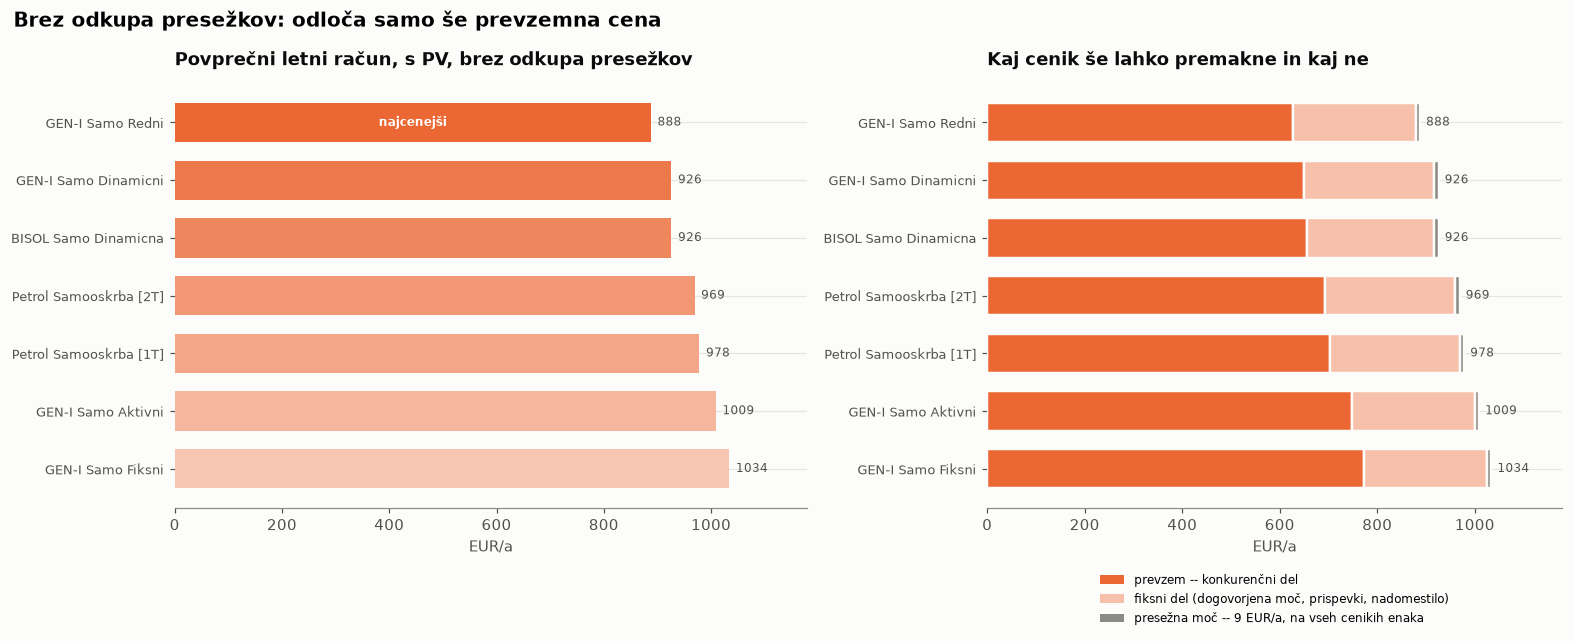

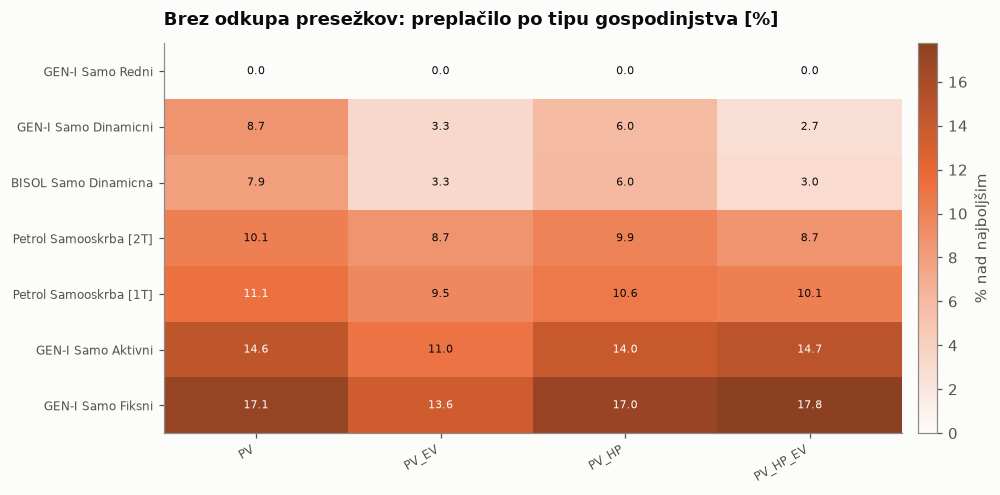

Dataset,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,
GENI_SAMO_REDNI,0.00,0.00,0.00,0.00
GENI_SAMO_DINAMICNI,8.65,3.32,6.01,2.69
BISOL_SAMO_DINAMICNA,7.86,3.26,6.03,2.96
PETROL_SAMOOSKRBA@2T,10.14,8.70,9.91,8.73
PETROL_SAMOOSKRBA@1T,11.10,9.53,10.56,10.13
GENI_SAMO_AKTIVNI,14.61,10.97,14.02,14.72
GENI_SAMO_FIKSNI,17.06,13.57,16.97,17.75


In [ ]:
### The ranking with no buyback, and how much of the bill is now beyond reach
by_group_pv0 = df_pv0.pivot_table(index="Option", columns="Dataset",
                                  values="Cost_EUR").reindex(pv0_summary.index)
by_group_pv0_rel = 100.0 * (by_group_pv0 / by_group_pv0.min() - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14.4, 6.0),
                         gridspec_kw={"width_ratios": [1.1, 1]})

ranked_bill_panel(axes[0], pv0_summary, REGIME_COLOR["nosale"],
                  "Povprečni letni račun, s PV, brez odkupa presežkov",
                  "EUR/a")

# What is left to choose between. With the credit gone the bill is import +
# fixed + excess, and only the first two differ between lists at all -- so the
# panel splits the bar into the part a contract moves and the part it cannot.
ypos = np.arange(len(pv0_summary))[::-1]
imp0 = pv0_summary["Import_EUR"].to_numpy()
fix0 = pv0_summary["Fixed_EUR"].to_numpy()
exc0 = pv0_summary["Excess_Power_EUR"].to_numpy()
# edgecolor=SURFACE gives the 2 px gap that keeps two stacked fills from
# reading as one long bar.
seg = dict(height=0.68, edgecolor=SURFACE, linewidth=1.6)
axes[1].barh(ypos, imp0, color=REGIME_COLOR["nosale"], **seg,
             label="prevzem -- konkurenčni del")
axes[1].barh(ypos, fix0, left=imp0,
             color=_mix(REGIME_COLOR["nosale"], "#ffffff", 0.58), **seg,
             label="fiksni del (dogovorjena moč, prispevki, nadomestilo)")
axes[1].barh(ypos, exc0, left=imp0 + fix0, color=MUTED, **seg,
             label="presežna moč -- na vseh cenikih enaka")
axes[1].set_yticks(ypos, [short_list_name(p) for p in pv0_summary.index], fontsize=8.5)
bar_labels(axes[1], ypos, (imp0 + fix0 + exc0))
axes[1].set_xlim(0, (imp0 + fix0 + exc0).max() * 1.14)
axes[1].set_xlabel("EUR/a")
axes[1].set_title("Kaj cenik še lahko premakne in kaj ne", loc="left")
# Explicit handles: the bars carry a SURFACE edge to hold the 2 px gap between
# segments, which at legend size would read as a hollow swatch.
below_legend(
    axes[1],
    [Patch(facecolor=REGIME_COLOR["nosale"], edgecolor="none"),
     Patch(facecolor=_mix(REGIME_COLOR["nosale"], "#ffffff", 0.58), edgecolor="none"),
     Patch(facecolor=MUTED, edgecolor="none")],
    ["prevzem -- konkurenčni del",
     "fiksni del (dogovorjena moč, prispevki, nadomestilo)",
     f"presežna moč -- {exc0.mean():.0f} EUR/a, na vseh cenikih enaka"],
    ncol=1, y=-0.13)
axes[1].grid(axis="x")
axes[1].spines["left"].set_visible(False)

fig.suptitle("Brez odkupa presežkov: odloča samo še prevzemna cena",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.2, 4.6))
overpay_heatmap(ax, by_group_pv0_rel, REGIME_COLOR["nosale"],
                "Brez odkupa presežkov: preplačilo po tipu gospodinjstva [%]", fig=fig)
fig.tight_layout()
plt.show()

by_group_pv0_rel.round(2)

In [ ]:
### Read-out: what is left to choose between when the surplus is worth nothing
lines = [f"{'list':26s}{'bill':>10s}{'import':>10s}{'fixed':>9s}{'vs best':>10s}"]
for pid, row in pv0_summary.iterrows():
    mark = "  <- cheapest" if pid == pv0_best else ""
    lines.append(f"{short_list_name(pid):26s}{row['Cost_EUR']:>10.2f}"
                 f"{row['Import_EUR']:>10.2f}{row['Fixed_EUR']:>9.2f}"
                 f"{row['Delta_pct']:>9.2f}%{mark}")

pv0_worst = pv0_summary.index[-1]
pv0_switch = pv0_summary.loc[pv0_worst, "Cost_EUR"] - pv0_summary.loc[pv0_best, "Cost_EUR"]
lines += [
    "",
    f"Best to worst is now {pv0_switch:.0f} EUR/a "
    f"({100 * pv0_switch / pv0_summary.loc[pv0_worst, 'Cost_EUR']:.1f} % of the bill), "
    f"against {pv_switch:.0f} EUR/a in chapter 2.",
    f"The buyback was carrying "
    f"{100 * (pv_switch - pv0_switch) / pv_switch:.0f} % of the spread between the best "
    f"and the worst contract.",
    "",
    "The bill, averaged over the households and the lists:",
    f"   import (competitive)      {pv0_summary['Import_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {pv0_summary['Import_EUR'].max() - pv0_summary['Import_EUR'].min():.2f}",
    f"   fixed (agreed power etc.) {pv0_summary['Fixed_EUR'].mean():8.2f} EUR/a  "
    f"spread across lists {pv0_summary['Fixed_EUR'].max() - pv0_summary['Fixed_EUR'].min():.2f}",
    f"   excess power (network)    {pv0_summary['Excess_Power_EUR'].mean():8.2f} EUR/a  "
    f"identical on every list by construction",
    "",
    f"And the surplus that is now worth nothing: "
    f"{df_pv0['Export_kWh'].mean():.0f} kWh/a per household, which the best chapter-2 "
    f"list would have paid",
    f"{pv_summary.loc[pv_best, 'Export_Credit_EUR']:.0f} EUR/a for "
    f"({100 * pv_summary.loc[pv_best, 'Export_Credit_EUR'] / pv_summary.loc[pv_best, 'Cost_EUR']:.0f} "
    f"% of that bill).",
]
print("\n".join(lines))

list                            bill    import    fixed   vs best
GEN-I Samo Redni              887.78    626.71   251.85     0.05%  <- cheapest
GEN-I Samo Dinamicni          925.99    650.57   266.20     5.77%
BISOL Samo Dinamicna          926.11    655.67   261.22     5.57%
Petrol Samooskrba [2T]        969.14    693.57   266.34     9.65%
Petrol Samooskrba [1T]        978.32    702.75   266.34    10.53%
GEN-I Samo Aktivni           1008.82    747.74   251.85    13.57%
GEN-I Samo Fiksni            1034.08    773.01   251.85    16.32%

Best to worst is now 146 EUR/a (14.1 % of the bill), against 210 EUR/a in chapter 2.
The buyback was carrying 30 % of the spread between the best and the worst contract.

The bill, averaged over the households and the lists:
   import (competitive)        692.86 EUR/a  spread across lists 146.30
   fixed (agreed power etc.)   259.38 EUR/a  spread across lists 14.49
   excess power (network)        9.22 EUR/a  identical on every list by construction

And 

## 4. What the right to sell the surplus is worth — best 3 and worst 3 contracts

Chapters 2 and 3 are two contracts for the same house. This chapter puts them on the same
row: the **best 3 and the worst 3** samooskrba options for a PV household, each shown once
with its buyback and once with the surplus priced at zero. The middle of the ranking is
dropped rather than plotted — it carries no finding the ends do not, and six rows is what
fits before a dumbbell chart stops being readable.

Ranking is by the **credited** bill, because that is the contract a household with a roof
would actually be offered; each row then carries its rank in the zero-export ranking too, so
a re-order between the two regimes is visible rather than hidden by the choice of sort.

Three things this comparison can settle that neither chapter can alone:

1. **The euro value of the buyback**, per contract — the horizontal distance between the two
   dots on each row. It is not the same on every one, because they do not pay the same rate
   for the same exported kWh, and one of them pays nothing at all.
2. **Whether the right to sell changes which contract to sign.** If the ranking survives
   zeroing the credit, a household can choose its contract without knowing whether it will be
   allowed to sell. If it does not, the two decisions are entangled.
3. **What the metering variant is worth next to it.** `Petrol Samooskrba` appears as both
   `[2T]` and `[1T]`, the only samooskrba list that publishes both — so the gap between those
   two rows is the price of the *meter*, measurable against the price of the *buyback* on
   every other row.

**One caution about reading euros here.** The zero-export bill is always the higher of the two,
so the gap is always "what the buyback is worth" — never "what the household saves". Both are
contracts available to the same household, so the right way to read the gap is as the maximum a
household should pay per year for a supplier that buys its surplus.

In [ ]:
### Best 3 and worst 3 contracts, each under both regimes
TOP_N = 6
ranked = list(pv_summary.index)                 # by credited bill, cheapest first
best = ranked[:TOP_N]
worst = ranked[-TOP_N:]
# Guard the small-catalogue case: with <= 2*TOP_N options the two ends would
# overlap and a contract would be drawn twice.
worst = [o for o in worst if o not in best]
shortlist = best + worst
middle = [o for o in ranked if o not in shortlist]

rank0 = {o: i for i, o in enumerate(pv0_summary.index)}
head = pd.DataFrame({
    "Credited_EUR": pv_summary.loc[shortlist, "Cost_EUR"],
    "NoSale_EUR": pv0_summary.loc[shortlist, "Cost_EUR"],
    "Variant": [hc.option_variant(o) for o in shortlist],
    "Structure": [hc.tariff_structure_label(o) for o in shortlist],
    "Buyback": [hc.buyback_rate_label(o) for o in shortlist],
    "End": ["best" if o in best else "worst" for o in shortlist],
    "Rank_Credited": [ranked.index(o) + 1 for o in shortlist],
    "Rank_NoSale": [rank0[o] + 1 for o in shortlist],
})
head["Worth_EUR"] = head["NoSale_EUR"] - head["Credited_EUR"]
head["Worth_pct"] = 100.0 * head["Worth_EUR"] / head["NoSale_EUR"]

print(f"{len(pv_summary)} samooskrba options ranked by the credited bill; showing the "
      f"best {len(best)} and worst {len(worst)}")
print(f"   best  : {', '.join(short_list_name(o) for o in best)}")
print(f"   worst : {', '.join(short_list_name(o) for o in worst)}")
if middle:
    print(f"   not shown ({len(middle)}): "
          f"{', '.join(short_list_name(o) for o in middle)}")
reordered = head[head["Rank_Credited"] != head["Rank_NoSale"]]
print(f"\nranking under the two regimes: "
      f"{'identical' if reordered.empty else 'differs on ' + ', '.join(short_list_name(o) for o in reordered.index)}")

head.rename(index=short_list_name).rename(columns={
    "Credited_EUR": "with buyback [EUR/a]",
    "NoSale_EUR": "no sale [EUR/a]",
    "Variant": "meter",
    "Structure": "billed on",
    "Buyback": "buyback terms",
    "End": "end of ranking",
    "Rank_Credited": "rank, credited",
    "Rank_NoSale": "rank, no sale",
    "Worth_EUR": "right to sell worth [EUR/a]",
    "Worth_pct": "worth [% of bill]",
}).round(2)

7 samooskrba options ranked by the credited bill; showing the best 6 and worst 1
   best  : GEN-I Samo Redni, GEN-I Samo Dinamicni, BISOL Samo Dinamicna, GEN-I Samo Aktivni, GEN-I Samo Fiksni, Petrol Samooskrba [2T]
   worst : Petrol Samooskrba [1T]

ranking under the two regimes: differs on GEN-I Samo Aktivni, GEN-I Samo Fiksni, Petrol Samooskrba [2T], Petrol Samooskrba [1T]


,with buyback [EUR/a],no sale [EUR/a],meter,billed on,buyback terms,end of ranking,"rank, credited","rank, no sale",right to sell worth [EUR/a],worth [% of bill]
Option,,,,,,,,,,
GEN-I Samo Redni,768.42,887.78,-,1T: ET 0.10290,0.05390 flat,best,1,1,119.36,13.45
GEN-I Samo Dinamicni,788.37,925.99,-,dynamic: SIPX + 0.01199,SIPX - 0.01199,best,2,2,137.62,14.86
BISOL Samo Dinamicna,790.73,926.11,-,dynamic: SIPX + 0.01300,SIPX - 0.01300,best,3,3,135.38,14.62
GEN-I Samo Aktivni,906.87,1008.82,-,4 blocks: 0.04090 -> 0.19290,"4 blocks, 0.00190 -> 0.14990",best,4,6,101.95,10.11
GEN-I Samo Fiksni,937.12,1034.08,-,4 blocks: 0.04590 -> 0.19790,"4 blocks, 0.00190 -> 0.14490",best,5,7,96.96,9.38
Petrol Samooskrba [2T],969.14,969.14,2T,2T: VT 0.12795 / MT 0.10795,no buyback,best,6,4,0.00,0.00
Petrol Samooskrba [1T],978.32,978.32,1T,1T: ET 0.11795,no buyback,worst,7,5,0.00,0.00


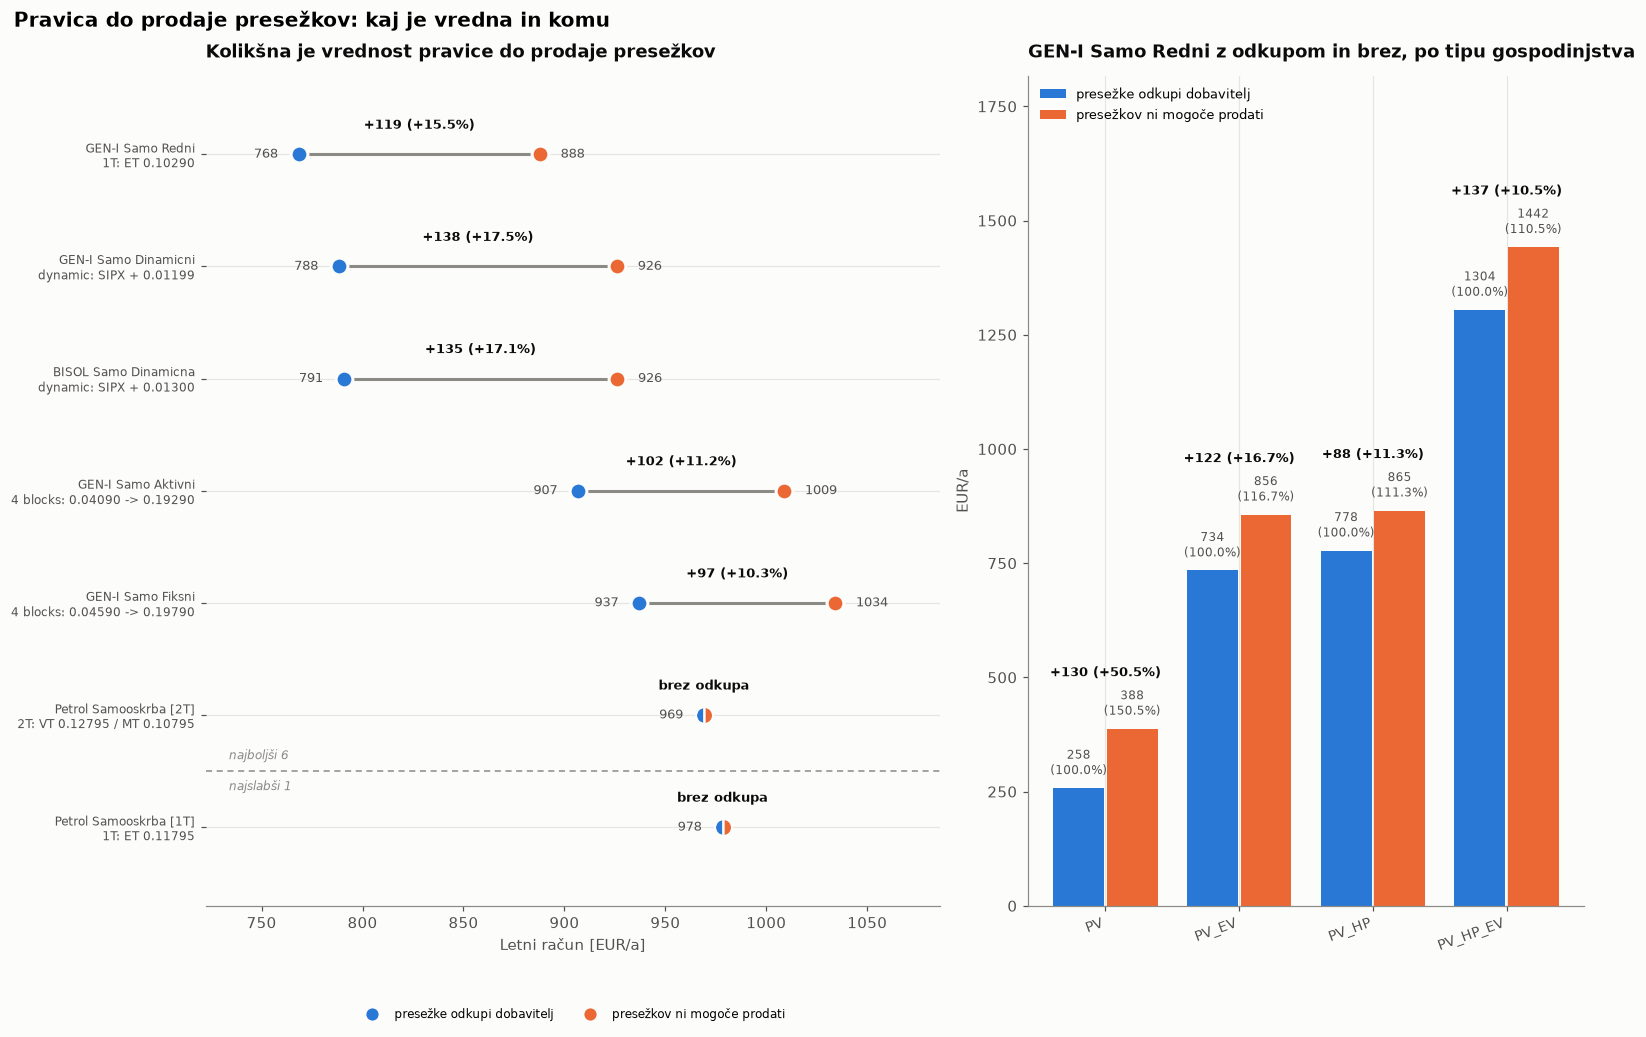

,credited,nosale,Worth_EUR,Export_kWh
Dataset,,,,
Fluvius_PV,257.6,387.6,130.0,2411.8
Fluvius_PV_EV,734.0,856.4,122.3,2269.6
Fluvius_PV_HP,777.6,865.2,87.6,1625.7
Fluvius_PV_HP_EV,1304.5,1442.0,137.5,2551.0


In [ ]:
### The two contracts on the same axis: one row per contract, one dot per regime
# A dumbbell rather than paired bars. The quantity of interest is the DISTANCE
# between two states of the same household on the same contract, and a connector
# shows a difference far better than two bar lengths the eye has to subtract.
# Both dots are labelled, so identity never rests on hue alone.
fig, axes = plt.subplots(1, 2, figsize=(14.6, 2.9 + 0.95 * len(head)),
                         gridspec_kw={"width_ratios": [1.32, 1]})

ypos = np.arange(len(head))[::-1]
span = head["NoSale_EUR"].max()
for y, (opt, row) in zip(ypos, head.iterrows()):
    axes[0].plot([row["Credited_EUR"], row["NoSale_EUR"]], [y, y],
                 color=MUTED, lw=2.0, zorder=1, solid_capstyle="round")
    if row["Worth_EUR"] < 0.5:
        # A list that never bought surpluses in the first place: the two regimes
        # land on the same euro, so one dot would hide the other and read as a
        # missing series. Split the marker instead -- half each hue, on the spot
        # they share.
        for regime, side in (("credited", "left"), ("nosale", "right")):
            axes[0].plot(row["Credited_EUR"], y, marker="o", ms=11, ls="",
                         color=REGIME_COLOR[regime], fillstyle=side,
                         mec=SURFACE, mew=1.2, zorder=3)
    else:
        # 2 px surface ring on each mark so a dot never dissolves into the connector
        for value, regime in ((row["Credited_EUR"], "credited"),
                              (row["NoSale_EUR"], "nosale")):
            axes[0].plot(value, y, marker="o", ms=11, color=REGIME_COLOR[regime],
                         mec=SURFACE, mew=2.0, zorder=3)
    axes[0].text(row["Credited_EUR"] - span * 0.010, y, f"{row['Credited_EUR']:.0f}",
                 va="center", ha="right", fontsize=8.5, color=INK_2)
    if row["Worth_EUR"] >= 0.5:
        worth_pct = row["Worth_EUR"] / row["Credited_EUR"] * 100 if row["Credited_EUR"] else 0
        axes[0].text(row["NoSale_EUR"] + span * 0.010, y, f"{row['NoSale_EUR']:.0f}",
                     va="center", ha="left", fontsize=8.5, color=INK_2)
        axes[0].text((row["Credited_EUR"] + row["NoSale_EUR"]) / 2, y + 0.20,
                     f"+{row['Worth_EUR']:.0f} (+{worth_pct:.1f}%)",
                     va="bottom", ha="center", fontsize=8.5, color=INK,
                     fontweight="semibold")
    else:
        axes[0].text((row["Credited_EUR"] + row["NoSale_EUR"]) / 2, y + 0.20,
                     "brez odkupa",
                     va="bottom", ha="center", fontsize=8.5, color=INK,
                     fontweight="semibold")

# The row label carries the contract, the meter variant and what it is billed
# on -- everything needed to tell two rows of the same supplier apart.
axes[0].set_yticks(ypos, [f"{short_list_name(o)}\n{head.loc[o, 'Structure']}"
                          for o in head.index], fontsize=8)
# A rule between the best block and the worst block: the middle of the ranking
# is missing, and a continuous axis would imply it is not.
if len(best) < len(head):
    axes[0].axhline(ypos[len(best) - 1] - 0.5, color=MUTED, lw=1.0, ls=(0, (4, 3)))
    axes[0].text(head["Credited_EUR"].min() * 0.955, ypos[len(best) - 1] - 0.42,
                 f"najboljši {len(best)}", va="bottom", ha="left", fontsize=8,
                 color=MUTED, style="italic")
    axes[0].text(head["Credited_EUR"].min() * 0.955, ypos[len(best) - 1] - 0.58,
                 f"najslabši {len(worst)}" + (f"  ({len(middle)} vmesnih ni prikazanih)"
                                              if middle else ""),
                 va="top", ha="left", fontsize=8, color=MUTED, style="italic")
axes[0].set_xlim(head["Credited_EUR"].min() * 0.94, span * 1.05)
axes[0].set_ylim(-0.7, len(head) - 0.3)
axes[0].set_xlabel("Letni račun [EUR/a]")
axes[0].set_title("Kolikšna je vrednost pravice do prodaje presežkov", loc="left")
axes[0].grid(axis="x")
axes[0].spines["left"].set_visible(False)
below_legend(axes[0],
             [plt.Line2D([], [], marker="o", ls="", ms=10, mec=SURFACE, mew=2.0,
                         color=REGIME_COLOR[r]) for r in ("credited", "nosale")],
             [REGIME_LABEL[r] for r in ("credited", "nosale")], ncol=2, y=-0.11)

# Per household type, on the best contract of each regime: who the buyback
# matters to. Grouped bars, hue = regime, type on the labelled axis.
best_pair = {"credited": (pv_best, df_pv), "nosale": (pv0_best, df_pv0)}
groups_pv = list(hc.PV_GROUPS)
by_group_regime = pd.DataFrame({
    regime: (frame[frame["Option"] == opt]
             .groupby("Dataset")["Cost_EUR"].mean().reindex(groups_pv))
    for regime, (opt, frame) in best_pair.items()
})
xpos = np.arange(len(groups_pv))
bar_w = 0.38
credited_values = by_group_regime["credited"].to_numpy()
for i, regime in enumerate(("credited", "nosale")):
    axes[1].bar(xpos + (i - 0.5) * (bar_w + 0.02), by_group_regime[regime],
                width=bar_w,
                color=REGIME_COLOR[regime], label=REGIME_LABEL[regime])
    for x, v, base in zip(xpos + (i - 0.5) * (bar_w + 0.02), by_group_regime[regime], credited_values):
        pct = v / base * 100 if base else 0
        axes[1].text(x, v + by_group_regime.to_numpy().max() * 0.015,
                     f"{v:.0f}\n({pct:.1f}%)", ha="center",
                     va="bottom", fontsize=8, color=INK_2)
# The delta is the finding, so it is written between the pair rather than left
# for the eye to subtract two bar heights.
for x, (lo, hi) in zip(xpos, zip(by_group_regime["credited"],
                                 by_group_regime["nosale"])):
    pct = (hi - lo) / lo * 100 if lo else 0
    axes[1].text(x, hi + by_group_regime.to_numpy().max() * 0.075,
                 f"+{hi - lo:.0f} (+{pct:.1f}%)", ha="center", va="bottom", fontsize=8.5,
                 color=INK, fontweight="semibold")
axes[1].set_xticks(xpos, [group_label(g) for g in groups_pv],
                   rotation=20, ha="right", fontsize=9)
axes[1].set_ylim(0, by_group_regime.to_numpy().max() * 1.26)
axes[1].set_ylabel("EUR/a")
axes[1].set_title(
    (f"{short_list_name(pv_best)} z odkupom in brez, po tipu gospodinjstva"
     if pv_best == pv0_best else
     "Na najcenejšem ceniku vsake možnosti, po tipu gospodinjstva"), loc="left")
axes[1].legend(fontsize=8.5, loc="upper left")
axes[1].grid(axis="y")

fig.suptitle("Pravica do prodaje presežkov: kaj je vredna in komu",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

by_group_regime.assign(
    Worth_EUR=lambda d: d["nosale"] - d["credited"],
    Export_kWh=df_pv.groupby("Dataset")["Export_kWh"].mean().reindex(groups_pv),
).round(1)

In [ ]:
### Read-out: is the contract choice separable from the right to sell?
per_hh = (df_pv.set_index(["Dataset", "Household", "Option"])["Cost_EUR"]
          .rename("credited").to_frame()
          .join(df_pv0.set_index(["Dataset", "Household", "Option"])["Cost_EUR"]
                .rename("nosale")))
per_hh["worth"] = per_hh["nosale"] - per_hh["credited"]
best_worth = per_hh.xs(pv_best, level="Option")["worth"]
export_by_unit = df_pv.groupby(["Dataset", "Household"])["Export_kWh"].first()
rel_share = pd.DataFrame({
    "credited": df_pv[df_pv["Option"] == pv_best].groupby("Dataset")["Cost_EUR"].mean(),
    "nosale": df_pv0[df_pv0["Option"] == pv0_best].groupby("Dataset")["Cost_EUR"].mean(),
}).reindex(hc.PV_GROUPS)
rel_share["pct"] = 100.0 * (rel_share["nosale"] / rel_share["credited"] - 1.0)

lines = [f"{'contract':30s}{'billed on':30s}{'credited':>10s}{'no sale':>10s}{'worth':>9s}"]
for opt, row in head.iterrows():
    mark = "  best" if row["End"] == "best" else "  worst"
    lines.append(f"{short_list_name(opt):30s}{row['Structure']:30s}"
                 f"{row['Credited_EUR']:>10.2f}{row['NoSale_EUR']:>10.2f}"
                 f"{row['Worth_EUR']:>9.2f}{mark}")

lines += ["", ]
if reordered.empty:
    lines += [
        "The ranking is IDENTICAL under both regimes, which is the useful answer: the choice of "
        "contract and the",
        "right to sell are SEPARABLE decisions. A household can sign the cheapest import "
        "contract without knowing",
        "yet whether it will be allowed to sell, and adding a buyback later cannot make it the "
        "wrong contract.",
    ]
else:
    lines += [
        "The two rankings DISAGREE, so the decisions are ENTANGLED -- "
        + ", ".join(f"{short_list_name(o)} is #{head.loc[o, 'Rank_Credited']} credited but "
                    f"#{head.loc[o, 'Rank_NoSale']} without" for o in reordered.index) + ".",
        "A household that cannot sell its surplus should not simply sign what its neighbour "
        "with a buyback signed.",
    ]

# The metering variant, priced against the buyback on the same chart.
pairs = sorted({hc.option_base_id(o) for o in pv_summary.index
                if hc.option_variant(o) != hc.VARIANT_NA})
if pairs:
    lines += ["", "What the METER is worth, on the lists that publish both variants:"]
    for base in pairs:
        two, one = f"{base}@{hc.VARIANT_2T}", f"{base}@{hc.VARIANT_1T}"
        d2, d1 = pv_summary.loc[two, "Cost_EUR"], pv_summary.loc[one, "Cost_EUR"]
        cheaper = "2T" if d2 < d1 else "1T"
        lines.append(f"   {base:22s} 2T {d2:8.2f} vs 1T {d1:8.2f} EUR/a  -> {cheaper} is "
                     f"cheaper by {abs(d2 - d1):.2f} EUR/a")
    lines.append(f"   Against {head['Worth_EUR'].max():.0f} EUR/a for the right to sell, the "
                 f"meter is the smaller decision on this sample --")
    lines.append("   but it is the one a household can change without changing supplier.")

lines += [
    "",
    f"On {short_list_name(pv_best)} the right to sell is worth "
    f"{best_worth.mean():.0f} EUR/a on average, and it is worth a very",
    "different amount to different roofs:",
    f"   most      {best_worth.idxmax()[0]} household {best_worth.idxmax()[1]}: "
    f"{best_worth.max():.0f} EUR/a "
    f"({export_by_unit.loc[best_worth.idxmax()]:.0f} kWh/a exported)",
    f"   least     {best_worth.idxmin()[0]} household {best_worth.idxmin()[1]}: "
    f"{best_worth.min():.0f} EUR/a "
    f"({export_by_unit.loc[best_worth.idxmin()]:.0f} kWh/a exported)",
    f"   community {len(best_worth)} households together: {best_worth.sum():.0f} EUR/a, "
    f"mean {best_worth.mean():.0f}, median {best_worth.median():.0f}",
    "",
    "In absolute euros it tracks how much a roof exports, but as a SHARE of the bill it "
    "runs the other way --",
    "the smaller the household, the more of its bill the buyback is:",
    *[f"   {group_label(g):8s} {rel_share.loc[g, 'credited']:7.0f} -> "
      f"{rel_share.loc[g, 'nosale']:.0f} EUR/a, "
      f"+{rel_share.loc[g, 'pct']:.0f} % of the credited bill"
      for g in rel_share.index],
    "",
    "Read that as a ceiling, not a saving: it is the most a household should pay per year "
    "for a supplier",
    "that buys its surplus, on top of whatever that supplier charges for the import side.",
    "",
    "And the number to keep next to any battery result: on the best contract, a PV "
    "household's whole",
    f"excess-power charge -- the ONE line a battery can move on this bill -- is "
    f"{pv_summary.loc[pv_best, 'Excess_Power_EUR']:.2f} EUR/a,",
    f"against {best_worth.mean():.0f} EUR/a for the right to sell and "
    f"{pv_switch:.0f} EUR/a for picking the right contract out of {len(pv_summary)}.",
]
print("\n".join(lines))

contract                      billed on                       credited   no sale    worth
GEN-I Samo Redni              1T: ET 0.10290                    768.42    887.78   119.36  best
GEN-I Samo Dinamicni          dynamic: SIPX + 0.01199           788.37    925.99   137.62  best
BISOL Samo Dinamicna          dynamic: SIPX + 0.01300           790.73    926.11   135.38  best
GEN-I Samo Aktivni            4 blocks: 0.04090 -> 0.19290      906.87   1008.82   101.95  best
GEN-I Samo Fiksni             4 blocks: 0.04590 -> 0.19790      937.12   1034.08    96.96  best
Petrol Samooskrba [2T]        2T: VT 0.12795 / MT 0.10795       969.14    969.14     0.00  best
Petrol Samooskrba [1T]        1T: ET 0.11795                    978.32    978.32     0.00  worst

The two rankings DISAGREE, so the decisions are ENTANGLED -- GEN-I Samo Aktivni is #4 credited but #6 without, GEN-I Samo Fiksni is #5 credited but #7 without, Petrol Samooskrba [2T] is #6 credited but #4 without, Petrol Samooskrba [1T]

## 5. *Samooskrba* or plain supply, once the surplus is worth nothing?

Chapter 3 zeroed the buyback and ranked the six *samooskrba* lists against each other. The
question one step out is the one it could not ask: **if the surplus is worth nothing, is the
*samooskrba* catalogue still the right shelf to be buying from at all?** The 25 plain supply
options of chapter 1 are sitting beside it, and nothing in a bill with no export credit
obviously prefers one shelf to the other.

This chapter puts all **32 options on one axis** — the 25 supply options and the 7 *samooskrba*
options, every exported kWh priced at zero on both — and asks it three times: for the 20
households with **no PV**, for the 20 **with PV**, and for **all 40 together**.

**Why the two catalogues can share an axis at all.** `si_dobava` and `si_samooskrba` differ in
exactly one term: the credit on an exported kWh. Zero that credit and the two schemes compute
the same import price, the same fixed charge and the same excess-power charge, on the same
interval-netted registers. So nothing below compares two billing regimes — it compares two
**rate cards**, and which scheme a row is billed under moves no euro. The cell below asserts
that on the rate builders both comparisons use, rather than leaving it as prose, and then
asserts that these frames reproduce chapters 1 and 3 exactly on the options they share.

What that does *not* claim is that the two schemes are interchangeable in general. `si_dobava`
has no buyback term at all, so handing it a negative net would credit an exported kWh at the full
retail rate, network charges and VAT included — the arbitrage the closing note warns about.
Nothing here does that: every bill below is built from a non-negative import, and the credit is
zero by construction on both shelves.

**Neither half is a shelf its household may actually buy from.** That is the finding's shape,
not a flaw in it:

| | supply lists (`si_dobava`) | *samooskrba* lists (`si_samooskrba`) |
|---|---|---|
| **no PV** | yes — this is chapter 1 | **no**: all 7 carry `zahteva_pv=True` |
| **with PV** | **no**: all 25 carry `dovoljuje_pv=False` | yes — this is chapter 3 |

`si_paketi.preveri_paket` raises `NezdruzljivPaket` on either diagonal, and the cell below reads
those two flags off the catalogue rather than trusting the sentence above. So each half of the
chapter is a **counterfactual on one side**: what the other shelf's rates would cost this
household if it were allowed to buy from them. That is exactly the quantity worth having,
because it prices something the household cannot shop for — the roof does not only change
which list is cheapest, it changes which list is *available*, and no ranking inside one
catalogue can show the cost of that.

The two directions are not symmetric in what they are for:

* **With PV** is the live decision. These households are held to the *samooskrba* shelf by
  `dovoljuje_pv`, and the supply rows are what they are being kept from. The gap is the price
  of the confinement.
* **No PV** is the control. Same rate cards, a demand profile with no roof behind it — so if
  the *samooskrba* lists come out dear on the PV households too, this half says whether that is
  the rates or the profile.

**What to expect.** A *samooskrba* list is sold as a different product, but it is not obviously
a dearer one: the rates are set per list, not per catalogue, and a supplier is free to reprint
its supply prices under a *samooskrba* heading — or not to. So the interesting number is not
whether there is a premium on average but **how much of the ranking the catalogue explains at
all**, next to the spread chapters 1–3 already measured *inside* each catalogue.

In [ ]:
### Both catalogues on both household sets, every exported kWh priced at zero
CAT_NO_PV_CACHE = cache_path("catalogue_no_pv", PER_GROUP)
CAT_PV_CACHE = cache_path("catalogue_pv_nosale", PER_GROUP)
RUN_CATALOGUE = False        # True -> recompute instead of reading the caches

# One list holding both catalogues. An `Option` is the same product here as in
# chapters 1-3 -- same id, same metering variant -- so the two frames below must
# reproduce those chapters exactly on the options they share, which is asserted.
ALL_OPTIONS = consumer_options + prosumer_options
PROSUMER_OPTIONS = set(prosumer_options)


def catalogue_of(option_id):
    """Which shelf an option is sold from -- the one categorical channel here."""
    return "samooskrba" if option_id in PROSUMER_OPTIONS else "dobava"


def read_catalogue_cache(path):
    """Cached frame, or None if it was written for another sample or power rule."""
    cached = pd.read_csv(path) if path.exists() else None
    if cached is not None and hc.agreed_power_tag(cached) != {hc.AGREED_POWER_TAG}:
        print(f"{path.name}: written under agreed power "
              f"{sorted(hc.agreed_power_tag(cached))} != {hc.AGREED_POWER_TAG!r}; "
              f"recomputing")
        cached = None
    if cached is not None and hc.sample_tag(cached) != {PER_GROUP}:
        print(f"{path.name}: written for per_group "
              f"{sorted(hc.sample_tag(cached), key=str)} != {PER_GROUP}; recomputing")
        cached = None
    return cached


# ~2 min for the pair at PER_GROUP=5. The no-PV households never export, so their
# bill needs no zeroing flag; the PV households are priced with buyback=False,
# which is chapter 3's regime extended to the supply catalogue.
cached = None if RUN_CATALOGUE else read_catalogue_cache(CAT_NO_PV_CACHE)
if cached is None:
    df_cat_no_pv = hc.no_pv_tariff_comparison(per_group=PER_GROUP,
                                              options=ALL_OPTIONS, verbose=True)
    df_cat_no_pv.to_csv(CAT_NO_PV_CACHE, index=False)
else:
    df_cat_no_pv = cached

cached = None if RUN_CATALOGUE else read_catalogue_cache(CAT_PV_CACHE)
if cached is None:
    df_cat_pv = hc.pv_tariff_comparison(per_group=PER_GROUP, options=ALL_OPTIONS,
                                        buyback=False, verbose=True)
    df_cat_pv.to_csv(CAT_PV_CACHE, index=False)
else:
    df_cat_pv = cached

# --- the four checks this chapter rests on -----------------------------------
# 1. Neither half is a shelf its household could actually be sold from. Read off
#    the catalogue flags rather than asserted from memory: `zahteva_pv` bars a
#    roofless household from a samooskrba list, `dovoljuje_pv` bars a roof from
#    a supply list, and `si_paketi.preveri_paket` raises on either.
blocked_for_pv = [o for o in consumer_options if not PAKETI[hc.option_base_id(o)].dovoljuje_pv]
needs_pv = [o for o in prosumer_options if PAKETI[hc.option_base_id(o)].zahteva_pv]
assert len(blocked_for_pv) == len(consumer_options), "some supply list admits a PV roof"
assert len(needs_pv) == len(prosumer_options), "some samooskrba list is sold without PV"

# 2. With the credit at zero the scheme label moves nothing. `si_dobava` and
#    `si_samooskrba` differ in one term -- the credit on the surplus -- so once
#    that term is zeroed the two price the same import rate, the same fixed
#    charge and the same excess-power charge. That is what makes the two frames
#    above poolable, so it is checked on the rate builders both of them use
#    rather than asserted in prose.
_probe_env = hc.build_env(hc.load_user(*reversed(hc.study_units(["Fluvius"], 1)[0])))
_probe_steps = 4 * hc.STEPS_PER_DAY
_probe_import = np.maximum(_probe_env.arr_consumption[:_probe_steps]
                           - _probe_env.arr_generation[:_probe_steps], 0.0)
for _opt in ("BISOL_FIKSNI99@1T", "GENI_SAMO_REDNI", "GENI_SAMO_AKTIVNI"):
    _rates = [hc._unit_import_rates(_probe_env, _opt, _probe_steps, s)
              for s in (hc.CONSUMER_SCHEME, hc.PROSUMER_SCHEME)]
    _charges = [hc._consumer_fixed_and_excess(_probe_env, _opt, _probe_steps,
                                              _probe_import, s)
                for s in (hc.CONSUMER_SCHEME, hc.PROSUMER_SCHEME)]
    assert np.array_equal(*_rates), f"{_opt}: import rate depends on the scheme"
    assert _charges[0] == _charges[1], f"{_opt}: fixed/excess depends on the scheme"

# 3. Nothing was recomputed differently: on the options they share, these frames
#    are bit-identical to chapter 1's and chapter 3's.
_key = ["Dataset", "Household", "Option"]
for _new, _old, _what in ((df_cat_no_pv, df_no_pv, "chapter 1"),
                          (df_cat_pv, df_pv0, "chapter 3")):
    _j = (_new.set_index(_key)["Cost_EUR"].rename("new").to_frame()
          .join(_old.set_index(_key)["Cost_EUR"].rename("old"), how="inner"))
    assert len(_j) == len(_old), f"{_what}: {len(_j)} of {len(_old)} rows matched"
    assert float((_j["new"] - _j["old"]).abs().max()) == 0.0, f"{_what} drifted"

# 4. And no surplus is worth anything anywhere in this chapter.
assert float(df_cat_pv["Export_Credit_EUR"].abs().max()) == 0.0

# --- one frame per household set ---------------------------------------------
# The no-PV frame has no export columns because it has no export; they are added
# as literal zeros so the two halves stack into one frame with one meaning per
# column, and `summarize_pv_tariffs` can rank all three the same way.
df_cat_no_pv_ext = df_cat_no_pv.assign(Import_EUR=df_cat_no_pv["Energy_EUR"],
                                       Export_Credit_EUR=0.0, Export_kWh=0.0,
                                       Buyback=False)
df_cat_all = pd.concat([df_cat_no_pv_ext, df_cat_pv], ignore_index=True)

SETS = {"no PV": df_cat_no_pv_ext, "with PV": df_cat_pv, "all": df_cat_all}
cat_summary = {}
for name, frame in SETS.items():
    summary = hc.summarize_pv_tariffs(frame)
    summary.insert(1, "Catalogue", [catalogue_of(o) for o in summary.index])
    cat_summary[name] = summary

by_group_cat = {
    name: frame.pivot_table(index="Option", columns="Dataset", values="Cost_EUR")
               .reindex(cat_summary[name].index)
    for name, frame in SETS.items()
}
by_group_cat_rel = {name: 100.0 * (t / t.min() - 1.0) for name, t in by_group_cat.items()}


def cheapest_of(summary, catalogue):
    """The cheapest option of one catalogue in a ranking of both."""
    return summary[summary["Catalogue"] == catalogue].index[0]


print(f"{len(ALL_OPTIONS)} price options on one axis: {len(consumer_options)} supply "
      f"lists a household with a roof may NOT sign,\n{len(prosumer_options)} samooskrba "
      f"lists a household without one may not sign. No battery, no buyback, full year.\n")
for name, frame in SETS.items():
    summary = cat_summary[name]
    units = frame.groupby(["Dataset", "Household"]).ngroups
    best_s, best_d = cheapest_of(summary, "samooskrba"), cheapest_of(summary, "dobava")
    ranks = [list(summary.index).index(o) + 1 for o in summary.index
             if summary.loc[o, "Catalogue"] == "samooskrba"]
    wins = int(summary[summary["Catalogue"] == "samooskrba"]["Cheapest_For"].sum())
    print(f"{name:8s} {units:2d} households   cheapest overall "
          f"{short_list_name(summary.index[0]):22s} {summary['Cost_EUR'].iloc[0]:7.0f} EUR/a")
    print(f"{'':8s} {'':2s}              best samooskrba  "
          f"{short_list_name(best_s):22s} {summary.loc[best_s, 'Cost_EUR']:7.0f} EUR/a "
          f"(rank {ranks[0]} of {len(summary)}, "
          f"+{summary.loc[best_s, 'Cost_EUR'] - summary.loc[best_d, 'Cost_EUR']:.0f} "
          f"EUR/a on the best supply list)")
    print(f"{'':8s} {'':2s}              samooskrba ranks {ranks}, cheapest for {wins} "
          f"of {units} households\n")

cat_summary["all"].rename(columns={
    "Cost_EUR": "Bill [EUR/a]",
    "Delta_EUR": "vs best [EUR/a]",
    "Delta_pct": "vs best [%]",
    "Worst_Delta_pct": "worst household [%]",
    "Energy_EUR": "energy net [EUR/a]",
    "Import_EUR": "import [EUR/a]",
    "Export_Credit_EUR": "buyback credit [EUR/a]",
    "Fixed_EUR": "fixed [EUR/a]",
    "Excess_Power_EUR": "excess power [EUR/a]",
    "Export_kWh": "exported [kWh/a]",
    "Cheapest_For": "cheapest for",
}).drop(columns=["Buyback", "exported [kWh/a]", "buyback credit [EUR/a]"]).round(2)

32 price options on one axis: 25 supply lists a household with a roof may NOT sign,
7 samooskrba lists a household without one may not sign. No battery, no buyback, full year.

no PV    20 households   cheapest overall BISOL Fiksni99 [1T]       1240 EUR/a
                         best samooskrba  GEN-I Samo Redni          1262 EUR/a (rank 3 of 32, +22 EUR/a on the best supply list)
                         samooskrba ranks [3, 8, 11, 27, 30, 31, 32], cheapest for 1 of 20 households

with PV  20 households   cheapest overall BISOL Fiksni99 [1T]        877 EUR/a
                         best samooskrba  GEN-I Samo Redni           888 EUR/a (rank 3 of 32, +10 EUR/a on the best supply list)
                         samooskrba ranks [3, 10, 12, 27, 29, 31, 32], cheapest for 4 of 20 households

all      40 households   cheapest overall BISOL Fiksni99 [1T]       1059 EUR/a
                         best samooskrba  GEN-I Samo Redni          1075 EUR/a (rank 3 of 32, +16 EUR/a on the best suppl

,Supplier,Catalogue,Structure,Variant,Households,Bill [EUR/a],vs best [EUR/a],vs best [%],worst household [%],energy net [EUR/a],fixed [EUR/a],excess power [EUR/a],import [EUR/a],cheapest for
Option,,,,,,,,,,,,,,
BISOL_FIKSNI99@1T,BISOL Energija,dobava,1T: ET 0.09900,1T,40,1058.67,4.50,0.53,4.84,781.47,267.45,9.75,781.47,27
BISOL_FIKSNI99@2T,BISOL Energija,dobava,2T: VT 0.10900 / MT 0.09400,2T,40,1066.87,12.71,1.39,4.01,789.68,267.45,9.75,789.68,0
GENI_SAMO_REDNI,GEN-I,samooskrba,1T: ET 0.10290,-,40,1074.67,20.51,1.54,6.91,806.85,258.08,9.75,806.85,5
GENI_DINAMICNI,GEN-I,dobava,dynamic: SIPX + 0.01199,-,40,1092.85,38.69,4.55,10.25,810.68,272.43,9.75,810.68,6
BISOL_FIKSNI_VEZAVA@2T,BISOL Energija,dobava,2T: VT 0.11600 / MT 0.09600,2T,40,1093.47,39.30,3.84,6.36,816.27,267.45,9.75,816.27,0
ELEN_DINAMICNA,Elektro energija,dobava,dynamic: SIPX + 0.01199,-,40,1095.63,41.47,4.93,11.71,810.68,275.21,9.75,810.68,0
BISOL_FIKSNI_VEZAVA@1T,BISOL Energija,dobava,1T: ET 0.10500,1T,40,1097.71,43.54,4.07,9.30,820.51,267.45,9.75,820.51,0
GENI_REDNI@2T,GEN-I,dobava,2T: VT 0.11990 / MT 0.09790,2T,40,1101.89,47.73,4.18,6.54,834.06,258.08,9.75,834.06,0
GENI_SAMO_DINAMICNI,GEN-I,samooskrba,dynamic: SIPX + 0.01199,-,40,1109.94,55.78,6.21,11.67,827.77,272.43,9.75,827.77,0


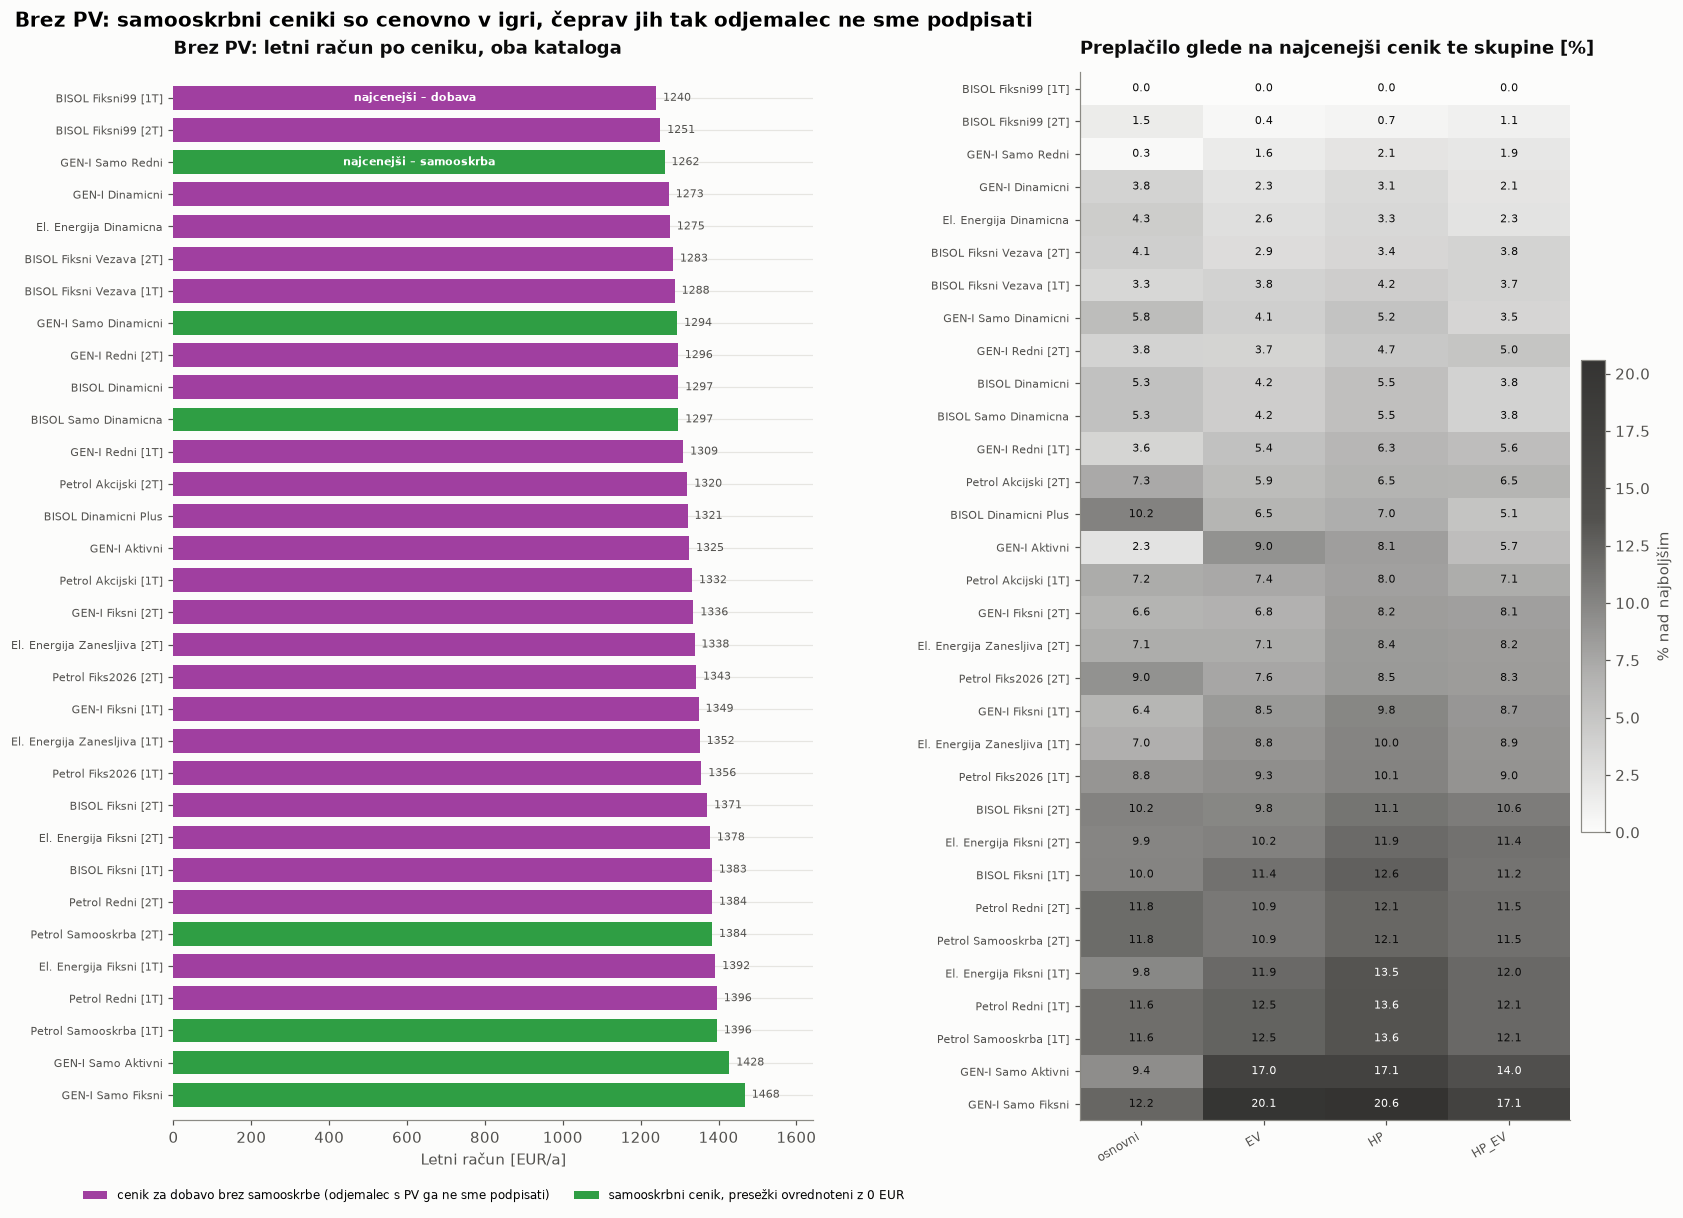

Dataset,Fluvius,Fluvius_EV,Fluvius_HP,Fluvius_HP_EV
Option,,,,
BISOL_FIKSNI99@1T,0.00,0.00,0.00,0.00
BISOL_FIKSNI99@2T,1.52,0.42,0.67,1.11
GENI_SAMO_REDNI,0.25,1.58,2.13,1.91
GENI_DINAMICNI,3.77,2.33,3.10,2.10
ELEN_DINAMICNA,4.34,2.59,3.28,2.25
BISOL_FIKSNI_VEZAVA@2T,4.07,2.88,3.45,3.76
BISOL_FIKSNI_VEZAVA@1T,3.35,3.79,4.19,3.73
GENI_SAMO_DINAMICNI,5.77,4.05,5.15,3.46
GENI_REDNI@2T,3.78,3.67,4.74,4.99


In [ ]:
### Both catalogues on one axis: the households with no roof
# `ranked_bill_panel` ramps a single hue because identity is on the y axis and
# only magnitude is left for the bar. Here the y axis still carries the identity,
# but which CATALOGUE a row is sold from is the comparison the chapter is about,
# so hue is spent on that instead. It costs nothing: every row in this chapter is
# under the same (zeroed) export regime, so the regime channel is unused.
def catalogue_bill_panel(ax, summary, title, xlabel="Letni račun [EUR/a]"):
    """Ranked annual bill, one bar per option, hue = which catalogue sells it."""
    ypos = np.arange(len(summary))[::-1]
    ax.barh(ypos, summary["Cost_EUR"], height=0.74,
            color=[CATALOGUE_COLOR[c] for c in summary["Catalogue"]])
    ax.set_yticks(ypos, [short_list_name(o) for o in summary.index], fontsize=7.5)
    bar_labels(ax, ypos, summary["Cost_EUR"].to_numpy(), fontsize=7.5)
    # The cheapest row of EACH catalogue is named in words inside its own bar, so
    # the answer never has to be read off hue.
    for catalogue in ("dobava", "samooskrba"):
        opt = cheapest_of(summary, catalogue)
        ax.text(summary.loc[opt, "Cost_EUR"] * 0.5,
                ypos[list(summary.index).index(opt)],
                f"najcenejši – {CATALOGUE_SHORT[catalogue]}", va="center",
                ha="center", fontsize=7.5, color="#ffffff", fontweight="semibold")
    ax.set_xlim(0, summary["Cost_EUR"].max() * 1.12)
    ax.set_ylim(-0.8, len(summary) - 0.2)
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left")
    ax.grid(axis="x")
    ax.spines["left"].set_visible(False)
    below_legend(ax, [Patch(facecolor=CATALOGUE_COLOR[c]) for c in CATALOGUE_ORDER],
                 [CATALOGUE_LABEL[c] for c in CATALOGUE_ORDER], ncol=2, y=-0.055)
    return ypos


def catalogue_figure(name, bill_title, heat_title, suptitle, figsize=(15.4, 11.2)):
    """The chapter's standard pair of panels for one household set.

    Left: every option ranked by its own bill. Right: the same rows against the
    cheapest option for each household TYPE -- the ranking is a mean and can hide
    a list that suits one kind of household and no other.

    The heatmap ramp is NEUTRAL rather than either catalogue's hue: its rows come
    from both shelves, and giving the magnitude one of the two categorical hues
    would read as a claim about which shelf the cell belongs to.
    """
    summary, rel = cat_summary[name], by_group_cat_rel[name]
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={"width_ratios": [1.22, 1]})
    catalogue_bill_panel(axes[0], summary, bill_title)
    overpay_heatmap(axes[1], rel, INK_2, heat_title, fig=fig,
                    cell_fontsize=6.5 if rel.shape[1] > 5 else 7.0,
                    label_fontsize=7.5)
    fig.suptitle(suptitle, fontsize=13, fontweight="semibold", x=0.012, ha="left")
    fig.tight_layout()
    plt.show()
    return rel


rel_no_pv = catalogue_figure(
    "no PV",
    "Brez PV: letni račun po ceniku, oba kataloga",
    "Preplačilo glede na najcenejši cenik te skupine [%]",
    "Brez PV: samooskrbni ceniki so cenovno v igri, čeprav jih tak odjemalec ne sme podpisati")

rel_no_pv.round(2)

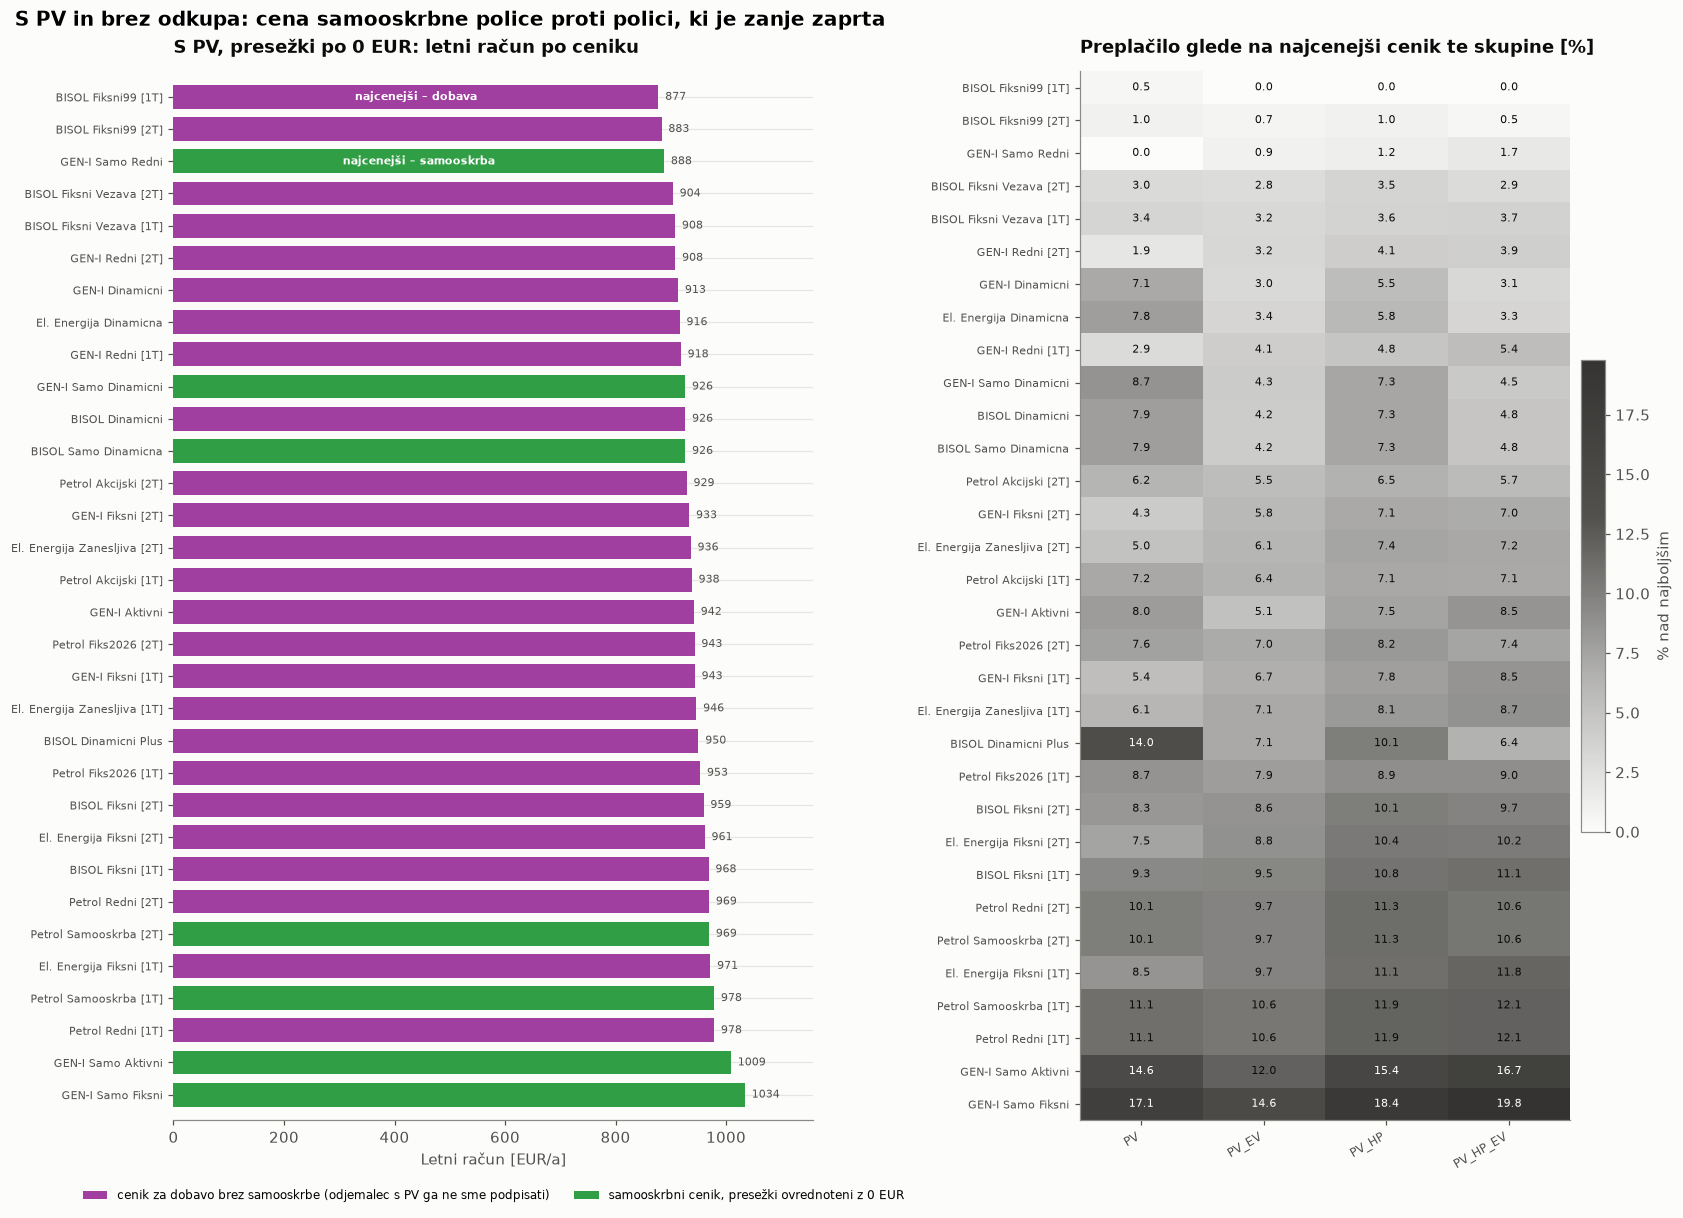

Dataset,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,
BISOL_FIKSNI99@1T,0.51,0.00,0.00,0.00
BISOL_FIKSNI99@2T,1.01,0.69,1.00,0.47
GENI_SAMO_REDNI,0.00,0.95,1.24,1.75
BISOL_FIKSNI_VEZAVA@2T,2.96,2.85,3.52,2.89
BISOL_FIKSNI_VEZAVA@1T,3.45,3.15,3.59,3.70
GENI_REDNI@2T,1.87,3.18,4.09,3.88
GENI_DINAMICNI,7.10,3.03,5.52,3.13
ELEN_DINAMICNA,7.82,3.36,5.85,3.33
GENI_REDNI@1T,2.94,4.10,4.82,5.45


In [ ]:
### The same 32 options on the households that actually have a roof
# Same two panels, same row-ordering rule, different households -- and this is
# the half that is a real decision: these households are confined to the green
# rows by `dovoljuje_pv`, and the purple rows are what they are being kept from.
rel_pv = catalogue_figure(
    "with PV",
    "S PV, presežki po 0 EUR: letni račun po ceniku",
    "Preplačilo glede na najcenejši cenik te skupine [%]",
    "S PV in brez odkupa: cena samooskrbne police proti polici, ki je zanje zaprta")

rel_pv.round(2)

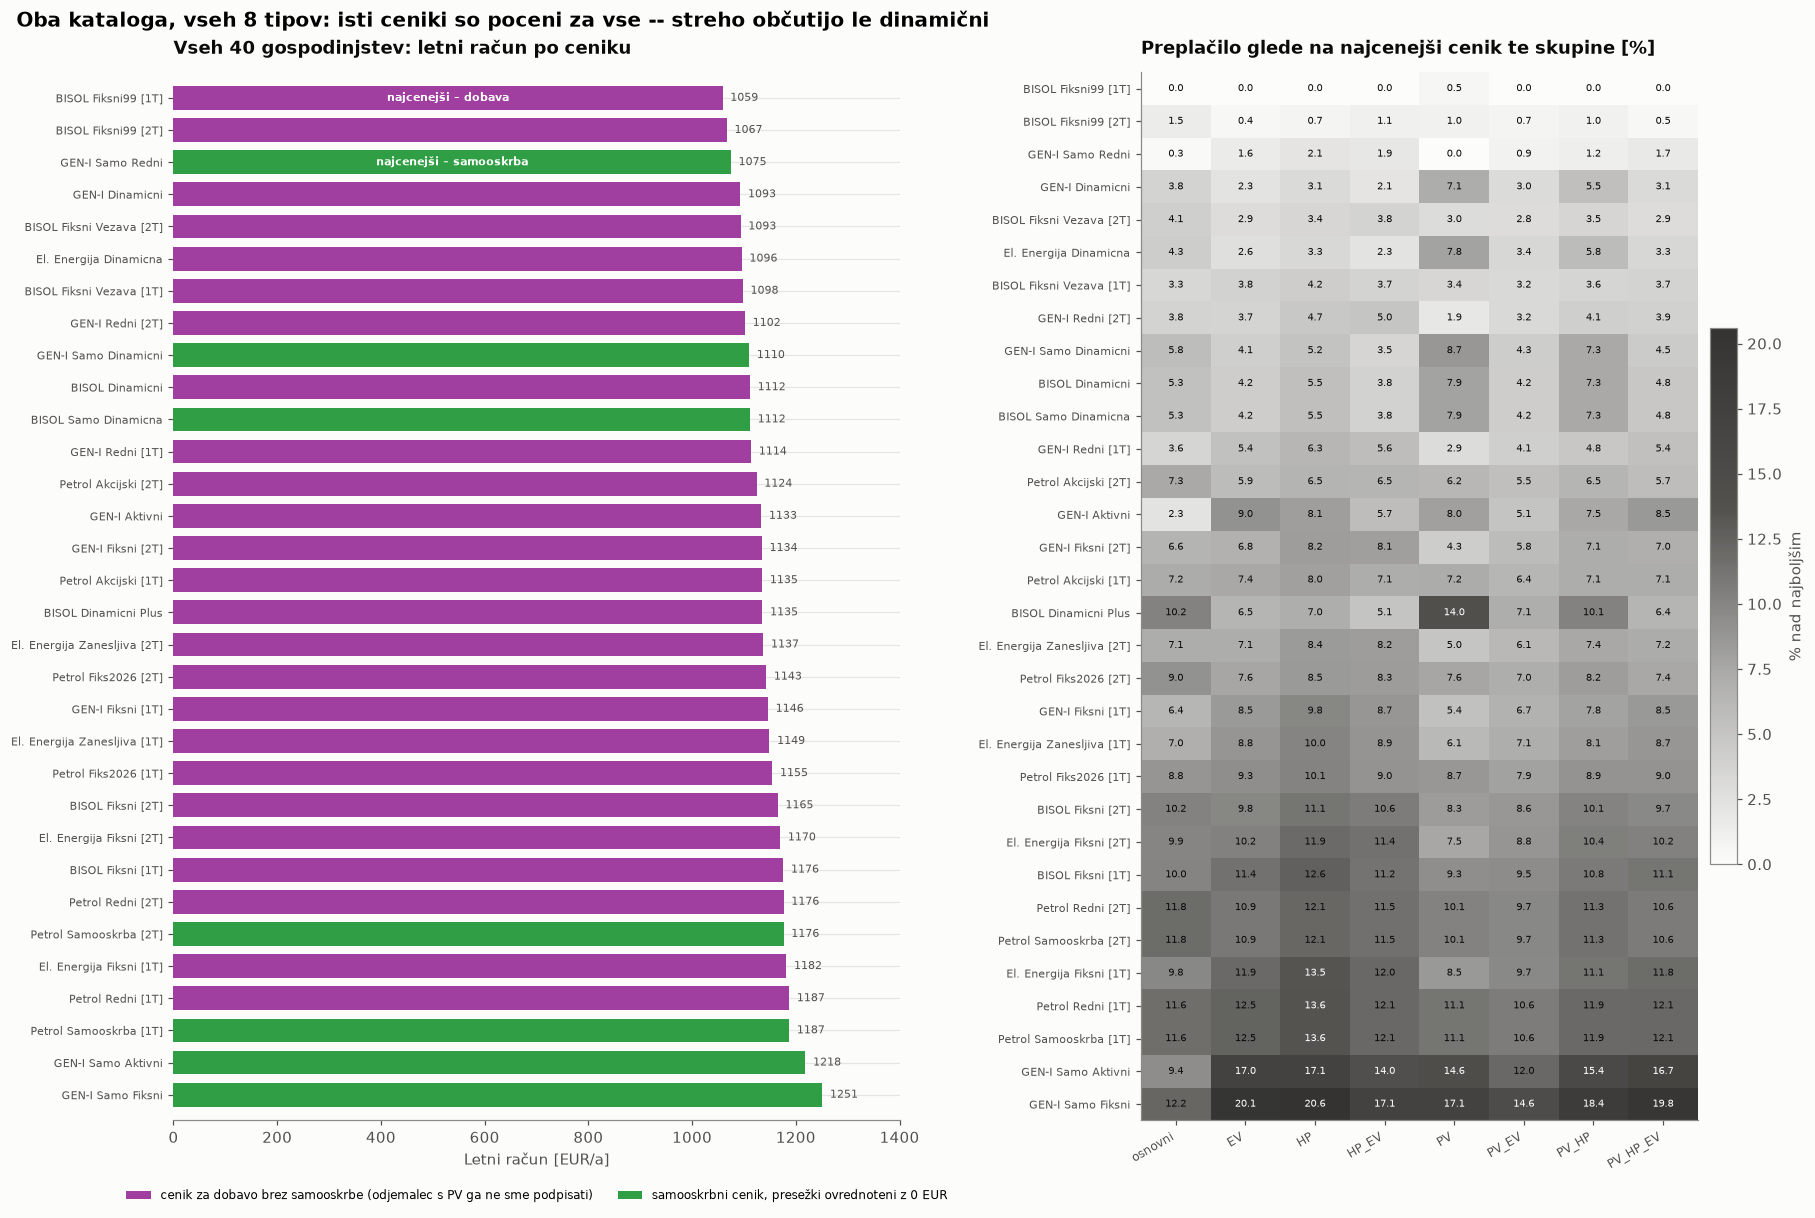

Dataset,Fluvius,Fluvius_EV,Fluvius_HP,Fluvius_HP_EV,Fluvius_PV,Fluvius_PV_EV,Fluvius_PV_HP,Fluvius_PV_HP_EV
Option,,,,,,,,
BISOL_FIKSNI99@1T,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
BISOL_FIKSNI99@2T,1.5,0.4,0.7,1.1,1.0,0.7,1.0,0.5
GENI_SAMO_REDNI,0.3,1.6,2.1,1.9,0.0,0.9,1.2,1.7
GENI_DINAMICNI,3.8,2.3,3.1,2.1,7.1,3.0,5.5,3.1
BISOL_FIKSNI_VEZAVA@2T,4.1,2.9,3.4,3.8,3.0,2.8,3.5,2.9
ELEN_DINAMICNA,4.3,2.6,3.3,2.3,7.8,3.4,5.8,3.3
BISOL_FIKSNI_VEZAVA@1T,3.3,3.8,4.2,3.7,3.4,3.2,3.6,3.7
GENI_REDNI@2T,3.8,3.7,4.7,5.0,1.9,3.2,4.1,3.9
GENI_SAMO_DINAMICNI,5.8,4.1,5.2,3.5,8.7,4.3,7.3,4.5


In [ ]:
### All 40 households at once, both catalogues, all 8 household types
# Pooling the two sets is legitimate here for one reason and one only: with the
# credit zeroed the two halves were billed on identical terms (check 2 above).
# What pooling buys is the 8-column heatmap -- one row per option, one column per
# household type, PV and no-PV side by side on the same colour scale, which is
# the only panel in the chapter that can show whether a roof changes the ANSWER
# rather than only the size of the bill.
#
# What it costs: the ranking column is a mean over households whose bills differ
# by 400 EUR/a between the two halves, so it is a ranking of price lists, never a
# statement about a typical household. Every delta beside it is measured per
# household first, which is the number that survives the mix.
rel_all = catalogue_figure(
    "all",
    "Vseh 40 gospodinjstev: letni račun po ceniku",
    "Preplačilo glede na najcenejši cenik te skupine [%]",
    "Oba kataloga, vseh 8 tipov: isti ceniki so poceni za vse -- streho občutijo le dinamični",
    figsize=(16.6, 11.2))

rel_all.round(1)

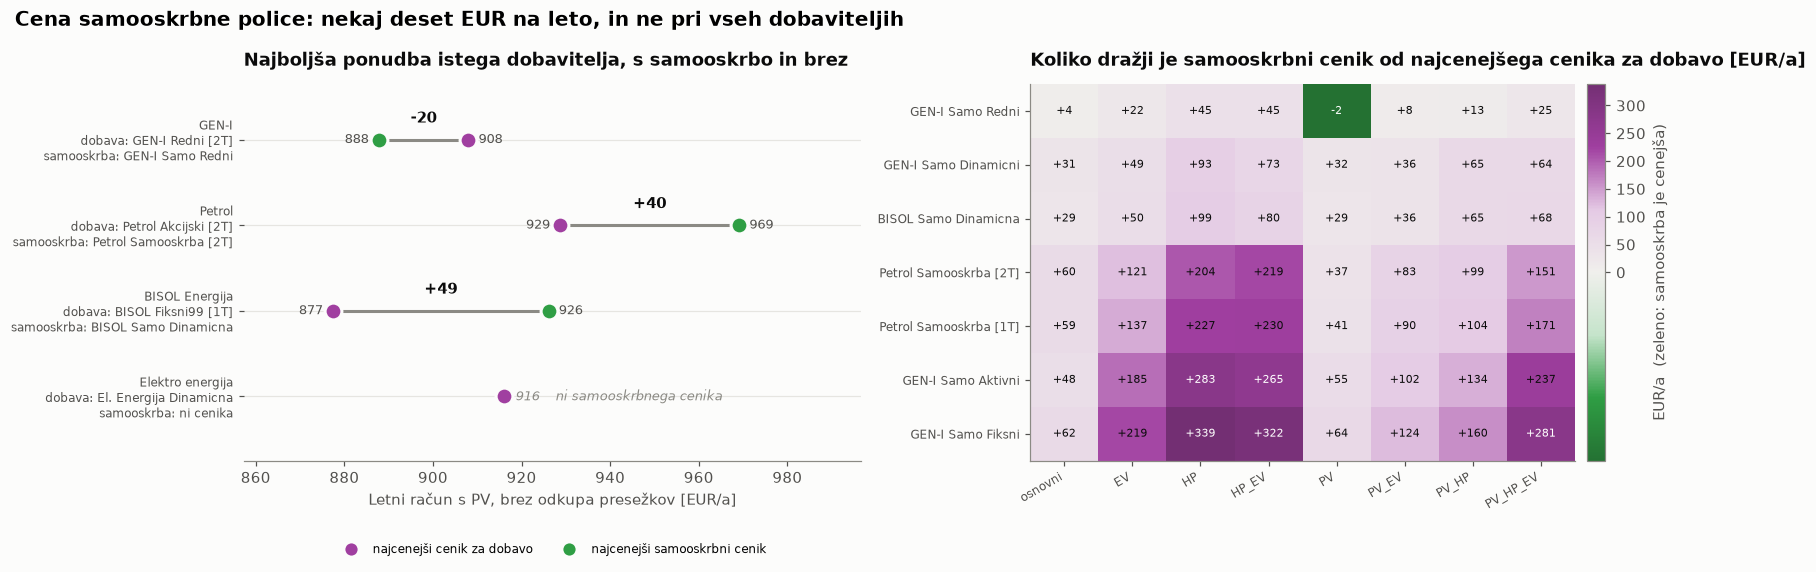

,najcenejša dobava [EUR/a],najcenejša samooskrba [EUR/a],razlika [EUR/a],cenikov za dobavo,samooskrbnih cenikov
Supplier,,,,,
GEN-I,908.00,887.78,-20.21,6,4
Petrol,928.71,969.14,40.42,6,2
BISOL Energija,877.45,926.11,48.67,8,1
Elektro energija,915.94,NaN,NaN,5,0


In [ ]:
### What the samooskrba shelf costs: against the whole supply shelf, and per supplier
# The quantity in both panels is a DIFFERENCE between two contracts for the same
# household, so it is computed per household and then averaged -- never as a
# difference of two group means, which would let a household mix decide the sign.
cat_all = df_cat_all.assign(Catalogue=[catalogue_of(o) for o in df_cat_all["Option"]])
best_supply = (cat_all[cat_all["Catalogue"] == "dobava"]
               .groupby(["Dataset", "Household"])["Cost_EUR"].min())
samo = cat_all[cat_all["Catalogue"] == "samooskrba"].copy()
samo["Premium_EUR"] = samo["Cost_EUR"] - samo.set_index(
    ["Dataset", "Household"]).index.map(best_supply)
premium_by_group = (samo.pivot_table(index="Option", columns="Dataset",
                                     values="Premium_EUR")
                    .reindex([o for o in cat_summary["all"].index
                              if catalogue_of(o) == "samooskrba"]))

# Per supplier, on the households that are actually held to this choice: the
# cheapest thing it will sell a roof against the cheapest thing it would sell the
# same house without one. It is a comparison of SHELVES, so a supplier with five
# supply lists and one samooskrba list is being read exactly as a customer would
# read it -- best offer against best offer.
pv_summary_cat = cat_summary["with PV"]
supplier_rows = []
for supplier in sorted(pv_summary_cat["Supplier"].unique()):
    shelf = pv_summary_cat[pv_summary_cat["Supplier"] == supplier]
    dobava = shelf[shelf["Catalogue"] == "dobava"]
    samoo = shelf[shelf["Catalogue"] == "samooskrba"]
    supplier_rows.append({
        "Supplier": supplier,
        "Dobava_Option": dobava.index[0] if len(dobava) else None,
        "Dobava_EUR": float(dobava["Cost_EUR"].iloc[0]) if len(dobava) else np.nan,
        "Samooskrba_Option": samoo.index[0] if len(samoo) else None,
        "Samooskrba_EUR": float(samoo["Cost_EUR"].iloc[0]) if len(samoo) else np.nan,
        "Lists_Dobava": len(dobava), "Lists_Samooskrba": len(samoo),
    })
supplier_premium = pd.DataFrame(supplier_rows).set_index("Supplier")
supplier_premium["Premium_EUR"] = (supplier_premium["Samooskrba_EUR"]
                                   - supplier_premium["Dobava_EUR"])
supplier_premium = supplier_premium.sort_values("Premium_EUR", na_position="last")

fig, axes = plt.subplots(1, 2, figsize=(15.4, 5.4),
                         gridspec_kw={"width_ratios": [1.06, 1]})

# --- left: one row per supplier, one dot per shelf ---------------------------
# A dumbbell, for the same reason as chapter 4: the finding is the DISTANCE
# between two contracts for the same household, and a connector shows a
# difference the eye would otherwise have to subtract from two bar lengths.
ypos = np.arange(len(supplier_premium))[::-1]
bills = supplier_premium[["Dobava_EUR", "Samooskrba_EUR"]].to_numpy()
lo_x, hi_x = float(np.nanmin(bills)), float(np.nanmax(bills))
span = hi_x - lo_x
for y, (supplier, row) in zip(ypos, supplier_premium.iterrows()):
    dob, sam = row["Dobava_EUR"], row["Samooskrba_EUR"]
    axes[0].plot(dob, y, marker="o", ms=11, color=CATALOGUE_COLOR["dobava"],
                 mec=SURFACE, mew=2.0, zorder=3)
    if np.isnan(sam):
        # A supplier with no samooskrba list at all is not a zero premium, it is
        # a closed door: one dot, and said in words rather than drawn as a gap.
        axes[0].text(dob + span * 0.03, y, f"{dob:.0f}    ni samooskrbnega cenika",
                     va="center", ha="left", fontsize=8.5, color=MUTED, style="italic")
        continue
    axes[0].plot([dob, sam], [y, y], color=MUTED, lw=2.0, zorder=1,
                 solid_capstyle="round")
    axes[0].plot(sam, y, marker="o", ms=11, color=CATALOGUE_COLOR["samooskrba"],
                 mec=SURFACE, mew=2.0, zorder=3)
    left, right = min(dob, sam), max(dob, sam)
    axes[0].text(left - span * 0.025, y, f"{left:.0f}", va="center", ha="right",
                 fontsize=8.5, color=INK_2)
    axes[0].text(right + span * 0.025, y, f"{right:.0f}", va="center", ha="left",
                 fontsize=8.5, color=INK_2)
    axes[0].text((dob + sam) / 2, y + 0.16, f"{row['Premium_EUR']:+.0f}",
                 va="bottom", ha="center", fontsize=9.5, color=INK,
                 fontweight="semibold")
# Which two lists a row compares belongs in the row label, not next to the dots:
# GEN-I's two offers are 20 EUR/a apart, and at that distance two names written
# under two dots would overlap.
axes[0].set_yticks(ypos, [
    f"{s}\ndobava: {short_list_name(r['Dobava_Option'])}\n"
    + (f"samooskrba: {short_list_name(r['Samooskrba_Option'])}"
       if pd.notna(r["Samooskrba_Option"]) else "samooskrba: ni cenika")
    for s, r in supplier_premium.iterrows()], fontsize=8)
axes[0].set_xlim(lo_x - span * 0.22, hi_x + span * 0.30)
axes[0].set_ylim(-0.75, len(supplier_premium) - 0.35)
axes[0].set_xlabel("Letni račun s PV, brez odkupa presežkov [EUR/a]")
axes[0].set_title("Najboljša ponudba istega dobavitelja, s samooskrbo in brez", loc="left")
axes[0].grid(axis="x")
axes[0].spines["left"].set_visible(False)
below_legend(axes[0],
             [plt.Line2D([], [], marker="o", ls="", ms=10, mec=SURFACE, mew=2.0,
                         color=CATALOGUE_COLOR[c]) for c in CATALOGUE_ORDER],
             ["najcenejši cenik za dobavo", "najcenejši samooskrbni cenik"],
             ncol=2, y=-0.19)

# --- right: the premium itself, per option and per household type ------------
# A signed quantity with a meaningful zero, so it is the one diverging scale in
# the notebook: the two poles are the two categories being compared, purple where
# the supply shelf wins and green where this samooskrba list beats everything on
# it, with a neutral midpoint at the tie. `TwoSlopeNorm` keeps that zero on the
# neutral colour: the negative side is genuinely small and a symmetric scale
# would flatten it to nothing.
values = premium_by_group.to_numpy()
diverging = LinearSegmentedColormap.from_list("catalogue_div", [
    _mix(CATALOGUE_COLOR["samooskrba"], "#0b0b0b", 0.30),
    CATALOGUE_COLOR["samooskrba"],
    _mix(CATALOGUE_COLOR["samooskrba"], "#ffffff", 0.72),
    "#f0efec",
    _mix(CATALOGUE_COLOR["dobava"], "#ffffff", 0.72),
    CATALOGUE_COLOR["dobava"],
    _mix(CATALOGUE_COLOR["dobava"], "#0b0b0b", 0.30)])
norm = TwoSlopeNorm(vmin=float(np.nanmin(values)), vcenter=0.0,
                    vmax=float(np.nanmax(values)))
im = axes[1].imshow(values, cmap=diverging, norm=norm, aspect="auto")
axes[1].set_xticks(range(premium_by_group.shape[1]),
                   [group_label(c) for c in premium_by_group.columns],
                   rotation=30, ha="right", fontsize=8)
axes[1].set_yticks(range(premium_by_group.shape[0]),
                   [short_list_name(o) for o in premium_by_group.index], fontsize=8)
axes[1].grid(False)
for r in range(values.shape[0]):
    for c in range(values.shape[1]):
        strong = norm(values[r, c]) > 0.86 or norm(values[r, c]) < 0.14
        axes[1].text(c, r, f"{values[r, c]:+.0f}", ha="center", va="center",
                     fontsize=7.5, color="#ffffff" if strong else INK)
axes[1].set_title("Koliko dražji je samooskrbni cenik od najcenejšega cenika za dobavo "
                  "[EUR/a]", loc="left")
fig.colorbar(im, ax=axes[1], fraction=0.045, pad=0.02,
             label="EUR/a  (zeleno: samooskrba je cenejša)")

fig.suptitle("Cena samooskrbne police: nekaj deset EUR na leto, in ne pri vseh dobaviteljih",
             fontsize=13, fontweight="semibold", x=0.012, ha="left")
fig.tight_layout()
plt.show()

supplier_premium[["Dobava_EUR", "Samooskrba_EUR", "Premium_EUR",
                  "Lists_Dobava", "Lists_Samooskrba"]].rename(columns={
    "Dobava_EUR": "najcenejša dobava [EUR/a]",
    "Samooskrba_EUR": "najcenejša samooskrba [EUR/a]",
    "Premium_EUR": "razlika [EUR/a]",
    "Lists_Dobava": "cenikov za dobavo",
    "Lists_Samooskrba": "samooskrbnih cenikov",
}).round(2)

In [ ]:
### Read-out: what the samooskrba shelf costs, and what it costs to pick wrongly on it
# Both quantities below are paired: the two shelves are compared on the SAME
# house and then averaged, never as a difference of two group means. `Delta_EUR`
# from the ranking is already per household; `Vs_Supply` is built the same way,
# against the cheapest supply option for that household rather than against the
# cheapest on average.
lock_in, vs_supply = {}, {}
for name, frame in SETS.items():
    tagged = frame.assign(Catalogue=[catalogue_of(o) for o in frame["Option"]])
    shelves = tagged.pivot_table(index=["Dataset", "Household"], columns="Catalogue",
                                 values="Cost_EUR", aggfunc="min")
    lock_in[name] = shelves["samooskrba"] - shelves["dobava"]
    samo_rows = tagged[tagged["Catalogue"] == "samooskrba"]
    vs_supply[name] = (samo_rows.assign(
        Vs_Supply=samo_rows["Cost_EUR"] - samo_rows.set_index(
            ["Dataset", "Household"]).index.map(shelves["dobava"]))
        .groupby("Option")["Vs_Supply"].mean())

pv_lock = lock_in["with PV"]
pv_sum = cat_summary["with PV"]
pv_best_samo = cheapest_of(pv_sum, "samooskrba")
pv_worst_samo = pv_sum[pv_sum["Catalogue"] == "samooskrba"].index[-1]
samo_spread = (pv_sum.loc[pv_worst_samo, "Cost_EUR"]
               - pv_sum.loc[pv_best_samo, "Cost_EUR"])
order = list(pv_sum.index)

lines = [f"{'samooskrbni cenik':26s}{'rank':>7s}{'račun':>9s}"
         f"{'vs najboljši [EUR/a]':>22s}{'vs najcenejša dobava':>22s}"]
for opt in [o for o in order if pv_sum.loc[o, "Catalogue"] == "samooskrba"]:
    lines.append(f"{short_list_name(opt):26s}{order.index(opt) + 1:>4d}/32"
                 f"{pv_sum.loc[opt, 'Cost_EUR']:>9.0f}"
                 f"{pv_sum.loc[opt, 'Delta_EUR']:>22.0f}"
                 f"{vs_supply['with PV'][opt]:>+22.0f}")

# Which supply lists a samooskrba list is a rate-card COPY of. Detected from the
# bills rather than by reading the two cenik pages: if a supplier reprints the
# same energy rates and the same monthly fee under a samooskrba heading, the two
# options land on the same euro for every household, and that is the check.
identical = []
for samo_opt in [o for o in order if pv_sum.loc[o, "Catalogue"] == "samooskrba"]:
    for dob_opt in [o for o in order if pv_sum.loc[o, "Catalogue"] == "dobava"]:
        drift = (df_cat_pv[df_cat_pv["Option"] == samo_opt]
                 .set_index(["Dataset", "Household"])["Cost_EUR"]
                 - df_cat_pv[df_cat_pv["Option"] == dob_opt]
                 .set_index(["Dataset", "Household"])["Cost_EUR"])
        if float(drift.abs().max()) == 0.0:
            identical.append((samo_opt, dob_opt))

geni = supplier_premium.loc["GEN-I"]
geni_dyn, geni_samo_dyn = (hc.option_paket("GENI_DINAMICNI"),
                           hc.option_paket("GENI_SAMO_DINAMICNI"))
dyn_premium = (pv_sum.loc["GENI_SAMO_DINAMICNI", "Cost_EUR"]
               - pv_sum.loc["GENI_DINAMICNI", "Cost_EUR"])
# The two GEN-I aktivni samooskrba lists against the supply aktivni list, block
# by block: four numbers each, so the claim is checked rather than eyeballed.
_blocks = ("soncna_ns", "soncna_vs", "osnovna", "konicna")
dearer_in_every_block = [
    o for o in ("GENI_SAMO_AKTIVNI", "GENI_SAMO_FIKSNI")
    if all(getattr(hc.option_paket(o), b) > getattr(hc.option_paket("GENI_AKTIVNI"), b)
           for b in _blocks)]
no_samo = list(supplier_premium.index[supplier_premium["Samooskrba_EUR"].isna()])

rank_no_pv, rank_pv = list(cat_summary["no PV"].index), list(cat_summary["with PV"].index)
shift = pd.DataFrame({
    "structure": [hc.option_paket(o).tip_cene.value for o in rank_no_pv],
    "shift": [rank_pv.index(o) - rank_no_pv.index(o) for o in rank_no_pv],
}).groupby("structure")["shift"].agg(["mean", "size"])

lines += [
    "",
    f"THE PRICE OF THE SHELF. Being confined to the samooskrba catalogue costs a PV "
    f"household {pv_lock.mean():.0f} EUR/a on",
    f"average -- {short_list_name(pv_best_samo)} at "
    f"{pv_sum.loc[pv_best_samo, 'Cost_EUR']:.0f} EUR/a against "
    f"{short_list_name(pv_sum.index[0])} at {pv_sum['Cost_EUR'].iloc[0]:.0f} EUR/a, "
    f"the cheapest of all 32. That is",
    f"{100 * pv_lock.mean() / pv_sum['Cost_EUR'].iloc[0]:.1f} % of the bill, and it is "
    f"not a uniform tax:",
    f"   {(pv_lock < 0).sum()} of {len(pv_lock)} PV households pay LESS on the samooskrba "
    f"shelf than on anything the supply shelf would sell them,",
    f"   median {pv_lock.median():.0f} EUR/a, best case {pv_lock.min():+.0f} EUR/a "
    f"({pv_lock.idxmin()[0]} household {pv_lock.idxmin()[1]}), worst case "
    f"{pv_lock.max():+.0f} EUR/a ({pv_lock.idxmax()[0]} household {pv_lock.idxmax()[1]}),",
    f"   and {pv_lock.sum():.0f} EUR/a for the {len(pv_lock)} of them together -- next to "
    f"{df_cat_pv.groupby(['Dataset', 'Household'])['Export_kWh'].first().sum():.0f} kWh/a "
    f"of surplus they are giving away.",
    "",
    "It is a difference between two per-kWh rates paid on the residual import, so it "
    "grows with what the roof does",
    "NOT cover -- smallest on the plain PV households, largest where a heat pump and an "
    "EV are behind the same roof:",
    *[f"   {group_label(g):10s} {lock_in['with PV'].xs(g).mean():6.1f} EUR/a"
      f"      {group_label(ng):8s} {lock_in['no PV'].xs(ng).mean():6.1f} EUR/a"
      for g, ng in zip(hc.PV_GROUPS, hc.NO_PV_GROUPS)],
    "   (right-hand column: the same household TYPE with no roof -- a different sample "
    "of houses, not the same ones,",
    "   and a shelf it may not buy from either way. It is there to show the effect is "
    "the demand, not the roof.)",
    "",
    f"THE PRICE OF CHOOSING BADLY ON IT. The same household moving from "
    f"{short_list_name(pv_best_samo)} to",
    f"{short_list_name(pv_worst_samo)} -- both samooskrba lists, both signable, same "
    f"roof, same year -- pays {samo_spread:.0f} EUR/a more.",
    f"That is {samo_spread / pv_lock.mean():.0f}x the cost of the shelf itself. Which "
    f"catalogue a household is confined to is a rounding error",
    "next to the choice it makes inside that catalogue -- the same finding chapters 1-3 "
    "reached from the other side.",
    "",
    f"WHY THE SHELF COSTS ANYTHING AT ALL. Not a samooskrba surcharge: "
    f"{len(identical)} of the {len(prosumer_options)} options are the same rate",
    "card as a supply list from the same supplier, to the cent, on every household --",
    *[f"   {short_list_name(s):26s} == {short_list_name(d)}" for s, d in identical],
    f"   {short_list_name(pv_best_samo):26s} is cheaper than EVERY GEN-I supply option "
    f"({pv_sum.loc[pv_best_samo, 'Cost_EUR']:.0f} against "
    f"{geni['Dobava_EUR']:.0f} EUR/a on {short_list_name(geni['Dobava_Option'])}),",
    f"   {'':26s} on an ET rate of "
    f"{hc.option_paket(pv_best_samo).et:.5f} against "
    f"{hc.option_paket('GENI_REDNI@1T').et:.5f} on the plain Redni.",
    f"   {short_list_name('GENI_SAMO_DINAMICNI'):26s} costs {dyn_premium:+.0f} EUR/a "
    f"against {short_list_name('GENI_DINAMICNI')} on an identical spread",
    f"   {'':26s} (SIPX + {geni_samo_dyn.pribitek_odjem:.5f} on both), because the "
    f"supply list caps SIPX at {geni_dyn.cap_sipx:.2f} EUR/kWh",
    f"   {'':26s} and the samooskrba one publishes no cap at all. The premium is "
    f"the cap, not the energy.",
    f"   {', '.join(short_list_name(o) for o in dearer_in_every_block):26s} are the "
    f"two dearest options of all 32, and all four of their tariff",
    f"   {'':26s} blocks are priced above the supply aktivni list's.",
    "",
    f"AND ONE SUPPLIER IS SIMPLY CLOSED. {', '.join(no_samo)} publishes "
    f"{int(supplier_premium.loc[no_samo[0], 'Lists_Dobava'])} supply options and no "
    f"samooskrba list at all,",
    "so a household that puts up a roof stops being able to buy from them. That is not a "
    "premium, and it is",
    "invisible in any table that ranks only the lists a household may sign.",
    "",
    "DOES THE ROOF CHANGE THE ANSWER? Barely, and where it does the reason is the tariff "
    "structure, not the catalogue:",
    *[f"   {s:10s} {row['mean']:+5.1f} places on average with a roof "
      f"({int(row['size'])} options)" for s, row in shift.iterrows()],
    "The dynamic lists lose ground on a PV household because what is left to import after "
    "the roof is the winter and",
    "the evening -- exactly the hours SIPX is expensive -- while a flat list charges the "
    "same rate whenever the import falls.",
    "",
    f"The excess-power charge is {pv_sum['Excess_Power_EUR'].mean():.2f} EUR/a and "
    f"identical on all 32 options in both catalogues,",
    "because no contract of either kind can move a network charge. It is still the only "
    "line a battery could.",
]
print("\n".join(lines))

samooskrbni cenik            rank    račun  vs najboljši [EUR/a]  vs najcenejša dobava
GEN-I Samo Redni             3/32      888                    12                   +11
GEN-I Samo Dinamicni        10/32      926                    50                   +49
BISOL Samo Dinamicna        12/32      926                    50                   +49
Petrol Samooskrba [2T]      27/32      969                    93                   +92
Petrol Samooskrba [1T]      29/32      978                   102                  +102
GEN-I Samo Aktivni          31/32     1009                   133                  +132
GEN-I Samo Fiksni           32/32     1034                   158                  +157

THE PRICE OF THE SHELF. Being confined to the samooskrba catalogue costs a PV household 10 EUR/a on
average -- GEN-I Samo Redni at 888 EUR/a against BISOL Fiksni99 [1T] at 877 EUR/a, the cheapest of all 32. That is
1.2 % of the bill, and it is not a uniform tax:
   4 of 20 PV households pay LESS on the

### What this notebook does and does not show

* **No battery, anywhere.** That is what makes every answer here a contract answer rather
  than a control answer, and it is also the limit: nothing below says what a battery is
  worth. It says what the *contract* is worth, which is the number a battery result has to
  beat before it is interesting. `MILP_horizon_comparison` and
  `Multuser_Battery_Size_Optimization` are the other half.
* **The excess-power charge is identical on every list, in every chapter**, because it is
  a network charge. It appears in all three totals so that each is a real bill, but it can
  never be a reason to prefer a contract — and it is the only line on the whole bill a
  battery can move. On the PV households it is ~9 EUR/a against a ~110 EUR/a buyback and a
  169 EUR/a spread between lists.
* **The profiles are already netted, so self-consumption is invisible.** The Fluvius
  columns are meter registers — offtake and injection — and the roof's own consumption was
  netted away before the data was written. Every euro in chapters 2–4 is therefore about
  the *residual* import and the *residual* surplus. Chapter 3 removes the value of the
  surplus, not the value of the roof: a household that could not sell a single kWh would
  still be far better off with the roof than without it, and no table here shows that
  saving because the data cannot.
* **Interval-level netting is physical, not contractual.** Within one 15-minute interval
  the meter registers the residual whatever the contract says. What the contract decides is
  only what a *surplus* is worth, which is exactly the term chapter 3 zeroes. Routing a
  no-buyback household through `si_dobava` instead would credit its exports at the full
  retail rate including network charges and VAT — unbounded arbitrage, and not a contract
  that exists.
* **Chapter 5 prices two shelves neither household may fully shop from.** Every supply list
  in the catalogue carries `dovoljuje_pv=False` and every *samooskrba* list `zahteva_pv=True`,
  so each half of that chapter has one counterfactual column: the rates of the shelf its
  household is barred from, applied to its own meter registers. It is a comparison of rates,
  not of offers — nothing there says a household with a roof may go and sign `BISOL Fiksni99`.
  What makes it meaningful anyway is that with the credit zeroed the two schemes bill identical
  terms, so the counterfactual bill is a real bill on real published rates and the only fiction
  is the signature. The chapter reads both flags off `si_paketi` rather than assuming them.
* **A row is a contract *and* a meter.** A *tarifni* list publishes VT/MT for a two-tariff
  meter and a single ET rate for a one-tariff meter; both are real products and the household
  picks one, so each appears as its own row tagged `[2T]` or `[1T]`, with the `Structure`
  column naming the rates. Rows with no tag have no such choice to offer — a 4-block
  (*aktivni*) or spot-linked (*dinamični*) list, or a *tarifni* list that publishes only one
  of the two. **No *samooskrba* list carries a tag at all**, and that is the product rather
  than a gap in the catalogue: self-consumption is billed on the single ET rate by
  construction — Petrol's cenik says so outright (*"v samooskrbi se vsa električna energija
  obračuna samo po ET"*) — so a household with a roof has no metering variant to choose and
  the six rows in chapters 2–4 are all untagged. The `et` field on an *aktivni* list is **not** a variant —
  it is the substitute rate for intervals with no 15-minute metering, and it is never offered
  as an alternative product, so it is correctly absent from the options.
* **The variant is priced by the pricing library, not re-derived here.** The 1T reading of a
  list is `dataclasses.replace(paket, vt=0, mt=0)`, which sends `si_obracun._cena_prevzema`
  down its ET branch and changes the supplier energy rate and nothing else — same network
  charges, same levies, same VAT, same fixed items. The variant is passed to
  `calculate_interval_price` as an object rather than registered in `PAKETI`, so no other
  notebook sees a catalogue that grew rows.
* **Three of the six samooskrba lists share a supplier and two share a tariff structure.**
  `GENI_SAMO_AKTIVNI` and `GENI_SAMO_FIKSNI` are both 4-block lists differing mainly in
  buyback, which is why they finish next to each other in both rankings. The comparison is
  a comparison of *catalogued products*, not of tariff structures in the abstract: a
  different set of suppliers would move the ranking without changing any mechanism.
* **`PER_GROUP` changes the sample, not the method.** It is the households drawn from each of
  the 8 Fluvius groups, so the panel stays balanced at any setting and the group mix never
  moves. Every comparison stamps its own `Per_Group` on every row and each chapter refuses a
  cache written at another setting, so the only thing a lower `PER_GROUP` costs is precision —
  the per-household spreads (`worst household [%]`, the best/worst call-outs) are the figures
  that move most, since they are order statistics over a smaller sample.
* **`Delta_pct` is measured per household, then averaged.** An option is never flattered by a
  household mix that suits it, and `Worst_Delta_pct` reports the single household it treats
  worst — a number no mean would show.
* **The agreed power is a policy, not an optimum.** Every chapter models a household that
  agrees exactly last month's per-block peak. Agreeing *less* in the expensive block 1 and
  paying the 1.05-weighted exceedance can be cheaper; that is a separate question, and what
  matters here is that the policy is identical for every household, every list and every
  chapter, so it cannot move a comparison. `MILP_horizon_comparison` section 1b has the
  argument and the alternatives.
* **A household that never touches its assigned agreed power is exempt from the
  excess-power charge** (since 24. 4. 2025, up to 43 kW). The households here manage the
  figure themselves and so pay it. A household choosing the exemption instead would read
  every table with the excess-power column removed — which, since that column is identical
  across lists, changes no ranking and no delta.
* **NET metering is absent on purpose.** It is closed to new consents and settles once a
  year rather than per interval, so it is neither a list a household can choose into nor a
  bill this evaluator can write. See `Multuser_Battery_Size_Optimization` for it as a
  legacy reference line for the households that still hold it.
* **One year, one price regime, 2026 rules.** The supplier rates are the catalogued ones at
  the dates in `si_paketi`, the network tariff and the 1.05 exceedance weighting are the
  2026 values (0.9 through 2025, 1.20 from 2028), and the SIPX series is 2024's. A dynamic
  list's standing next to a flat one is a claim about *that* market year, and the dynamic
  lists are the ones that would move most in another.